# SGIO — MyFitnessPal Temporal-Split Validation
## IEEE J-BHI Paper: Full Analysis Notebook

This notebook runs the complete MFP analysis for the paper:
1. Data exploration & cohort selection
2. Single-user demo (single-obs + multi-obs comparison)
3. Cohort temporal-split validation (N=200)
4. Statistical tests (Wilcoxon signed-rank)
5. Paper-ready figures (6-panel validation figure)
6. Paper-ready LaTeX tables

**Prerequisites:** `smgil` package installed, data files at paths below.

## 0. Configuration

In [59]:
from pathlib import Path

# ── Absolute base (one level up from data-processing/) ─────────────────────
BASE = Path("/home/farzin/Diet Recommendation/IEEE Paper MFP and AI4")
DATA_DIR = BASE / "data"

# ── Data paths ──────────────────────────────────────────────────────────────
MFP_CSV          = DATA_DIR / "myfitnesspal/processed/myfitnesspal_foods.csv"
MFP_USERS_CSV    = DATA_DIR / "myfitnesspal/processed/myfitnesspal_users.csv"
MFP_SIM_JSON     = DATA_DIR / "similarity/myfitnesspal_to_usda.json"
USDA_PARQUET     = DATA_DIR / "similarity/usda_index.parquet"
FNDDS_PATH       = DATA_DIR / "nhanes/2017/rawdata/DRXFCD_J.xpt"
NUTRIENT_CSV     = DATA_DIR / "usda/2017-2018/processed/nutrient_values.csv"

# ── Model hyperparameters ───────────────────────────────────────────────────
K_NEIGHBORS      = 5
N_COHORT         = 200
MAX_ITER         = 4
COST_THRESHOLD   = 100
RANDOM_SEED      = 42
MIN_DAYS         = 14
MIN_FOODS_PER_DAY = 5
MIN_CALORIES     = 800
MAX_CALORIES     = 5000

MFP_NUTRIENT_COLS = ["sodium", "sat fat", "sugar", "chol", "fat",
                     "fiber", "potass.", "calcium", "protein"]

# ── Outputs ─────────────────────────────────────────────────────────────────
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
COHORT_CSV = OUTPUT_DIR / "smgil_mfp_temporal_validation.csv"
FIG_PREFIX = OUTPUT_DIR / "smgil_mfp_validation"

# ── Sanity check ────────────────────────────────────────────────────────────
for name, p in [
    ("MFP foods",    MFP_CSV),
    ("MFP users",    MFP_USERS_CSV),
    ("Similarity",   MFP_SIM_JSON),
    ("USDA parquet", USDA_PARQUET),
    ("FNDDS",        FNDDS_PATH),
    ("Nutrients",    NUTRIENT_CSV),
]:
    status = "✅" if p.exists() else "❌ MISSING"
    print(f"  {status}  {name}: {p}")

  ✅  MFP foods: /home/farzin/Diet Recommendation/IEEE Paper MFP and AI4/data/myfitnesspal/processed/myfitnesspal_foods.csv
  ✅  MFP users: /home/farzin/Diet Recommendation/IEEE Paper MFP and AI4/data/myfitnesspal/processed/myfitnesspal_users.csv
  ✅  Similarity: /home/farzin/Diet Recommendation/IEEE Paper MFP and AI4/data/similarity/myfitnesspal_to_usda.json
  ✅  USDA parquet: /home/farzin/Diet Recommendation/IEEE Paper MFP and AI4/data/similarity/usda_index.parquet
  ✅  FNDDS: /home/farzin/Diet Recommendation/IEEE Paper MFP and AI4/data/nhanes/2017/rawdata/DRXFCD_J.xpt
  ✅  Nutrients: /home/farzin/Diet Recommendation/IEEE Paper MFP and AI4/data/usda/2017-2018/processed/nutrient_values.csv


In [60]:
import smgil
print([x for x in dir(smgil) if not x.startswith("_")])

import smgil.tradeoff
print([x for x in dir(smgil.tradeoff) if not x.startswith("_")])

['A4F_DASH_CONSTRAINTS', 'DASH_CONSTRAINTS', 'MFP_DASH_CONSTRAINTS', 'a4f_preprocessing', 'build_A_b', 'build_A_b_a4f', 'build_A_b_mfp', 'build_a4f_crosswalk', 'build_a4f_daily_matrix', 'build_a4f_observation_vector', 'build_crosswalk', 'build_mfp_crosswalk', 'build_mfp_daily_matrix', 'build_mfp_observation_vector', 'build_observation_vector', 'check_observed_intake', 'config', 'constraints', 'make_gurobi_env', 'mfp_preprocessing', 'preprocessing', 'recover_theta', 'reporting', 'run_smgil_tradeoff', 'run_smgil_tradeoff_multi_obs', 'smgil', 'smgil_multi_obs', 'solver', 'tradeoff', 'tune_weights', 'validation']
['np', 'run_smgil_tradeoff', 'run_smgil_tradeoff_multi_obs', 'smgil', 'smgil_multi_obs', 'tune_weights']


## 1. Imports

In [61]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker

# smgil package
from smgil import build_crosswalk, build_A_b_mfp, MFP_DASH_CONSTRAINTS
from smgil import run_smgil_tradeoff
from smgil.mfp_preprocessing import (
    build_mfp_crosswalk,
    build_mfp_observation_vector,
    build_mfp_daily_matrix,
)
from smgil.tradeoff import tune_weights, run_smgil_tradeoff_multi_obs
from smgil.validation import project_mfp_holdout, compute_distances
from smgil.reporting import print_full_report, summary_table

# ── Matplotlib style ───────────────────────────────────────────────────────
matplotlib.rcParams.update({
    "font.family":       "serif",
    "font.size":         9,
    "axes.titlesize":    9,
    "axes.labelsize":    8,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
    "legend.fontsize":   7,
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
})

# Color palette consistent with paper figures
ITER_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
NAT_COLOR   = "#7f7f7f"

print("Imports OK.")

Imports OK.


## 2. Load Data & Build Crosswalks

In [62]:
print("Loading MFP foods CSV ...")
mfp_df = pd.read_csv(MFP_CSV, low_memory=False)
print(f"  mfp_df shape: {mfp_df.shape}")
print(f"  Columns: {list(mfp_df.columns)}")

print("\nLoading MFP users CSV ...")
users_df = pd.read_csv(MFP_USERS_CSV, low_memory=False)
print(f"  users_df shape: {users_df.shape}")
print(f"  Columns: {list(users_df.columns)}")

Loading MFP foods CSV ...
  mfp_df shape: (6502747, 26)
  Columns: ['user_id', 'date', 'meal_name', 'meal_idx', 'calories', 'carbs', 'fat', 'protein', 'sodium', 'sugar', 'description', 'food_name', 'brand', 'flavor', 'serving_size', 'fiber', 'potass.', 'iron', 'calcium', 'sat fat', 'chol', 'vit a', 'vit c', 'trn fat', 'mon fat', 'ply fat']

Loading MFP users CSV ...
  users_df shape: (587187, 36)
  Columns: ['user_id', 'date', 'calories', 'carbs', 'fat', 'protein', 'sodium', 'sugar', 'goal_calories', 'goal_carbs', 'goal_fat', 'goal_protein', 'goal_sodium', 'goal_sugar', 'fiber', 'goal_fiber', 'potass.', 'goal_potass.', 'iron', 'goal_iron', 'calcium', 'goal_calcium', 'sat fat', 'goal_sat fat', 'chol', 'goal_chol', 'vit a', 'vit c', 'goal_vit a', 'goal_vit c', 'trn fat', 'goal_trn fat', 'mon fat', 'goal_mon fat', 'ply fat', 'goal_ply fat']


In [63]:
# Quick data overview
print("=== mfp_df (food-level) sample ===")
display(mfp_df.head(5))

print("\n=== users_df (day-level) sample ===")
display(users_df.head(5))

print(f"\nUnique users in mfp_df:    {mfp_df['user_id'].nunique()}")
print(f"Unique users in users_df:  {users_df['user_id'].nunique()}")
print(f"Date range (mfp_df):       {mfp_df['date'].min()} – {mfp_df['date'].max()}")

=== mfp_df (food-level) sample ===


,user_id,date,meal_name,meal_idx,calories,carbs,fat,protein,sodium,sugar,...,potass.,iron,calcium,sat fat,chol,vit a,vit c,trn fat,mon fat,ply fat
0,1,2014-09-14,MY food,1,412,29.00,24.00,21.00,258.00,29.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2014-09-14,MY food,1,170,25.00,5.00,20.00,260.00,2.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2014-09-14,MY food,1,176,33.00,1.00,5.00,195.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2014-09-14,MY food,1,342,34.00,12.00,24.00,402.00,34.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2014-09-14,MY food,1,180,22.00,7.00,21.00,310.00,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== users_df (day-level) sample ===


,user_id,date,calories,carbs,fat,protein,sodium,sugar,goal_calories,goal_carbs,...,vit a,vit c,goal_vit a,goal_vit c,trn fat,goal_trn fat,mon fat,goal_mon fat,ply fat,goal_ply fat
0,1,2014-09-14,2924.00,340.00,114.00,186.00,3658.00,109.00,3173.00,396.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2014-09-15,2430.00,96.00,37.00,50.00,855.00,63.00,1572.00,196.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2014-09-16,1862.00,158.00,54.00,114.00,2215.00,100.00,1832.00,229.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2014-09-17,2251.00,187.00,60.00,98.00,1765.00,105.00,1685.00,210.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2014-09-18,2001.00,113.00,81.00,202.00,1101.00,71.00,1597.00,199.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Unique users in mfp_df:    9896
Unique users in users_df:  9896
Date range (mfp_df):       2014-09-14 – 2015-04-09


In [64]:
# Install ijson first
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "ijson"], check=True)

Defaulting to user installation because normal site-packages is not writeable


CompletedProcess(args=['/bin/python3', '-m', 'pip', 'install', 'ijson'], returncode=0)

In [65]:
import ijson
from pathlib import Path

def build_mfp_crosswalk_stream(mfp_similarity_json, verbose=True):
    path = Path(mfp_similarity_json)
    print(f"Loading {path.name} ({path.stat().st_size/1e6:.0f} MB) via streaming parser ...")

    name_to_id = {}
    similarity_index = {}
    skipped = 0

    with open(path, "rb") as f:
        try:
            # ijson streams top-level key-value pairs one at a time
            parser = ijson.kvitems(f, "")
            for key, value in parser:
                try:
                    mfp_id = int(key)
                    name = value["name"].strip()
                    neighbors = sorted(
                        value.get("neighbors", []),
                        key=lambda n: n.get("final_score", 0.0),
                        reverse=True,
                    )
                    name_to_id[name] = mfp_id
                    similarity_index[mfp_id] = {"name": name, "neighbors": neighbors}
                except Exception:
                    skipped += 1
        except Exception as e:
            # Stream stops at corruption — everything parsed so far is valid
            print(f"  Stream stopped at corruption: {e}")

    print(f"  Recovered: {len(name_to_id):,} entries  |  skipped: {skipped}")
    return name_to_id, similarity_index

name_to_id, similarity_index = build_mfp_crosswalk_stream(MFP_SIM_JSON)

Loading myfitnesspal_to_usda.json (444 MB) via streaming parser ...
  Stream stopped at corruption: parse error: premature EOF
                                       
                     (right here) ------^

  Recovered: 403,303 entries  |  skipped: 0


In [66]:
print("Building MFP crosswalk (name→USDA ID + similarity index) ...")
name_to_id, similarity_index = build_mfp_crosswalk_stream(MFP_SIM_JSON)
print(f"  name_to_id entries:     {len(name_to_id):,}")
print(f"  similarity_index items: {len(similarity_index):,}")

print("\nBuilding NHANES crosswalk (FNDDS → USDA) ...")
nhanes_crosswalk = build_crosswalk(fndds_path=FNDDS_PATH, usda_parquet_path=USDA_PARQUET)
print(f"  nhanes_crosswalk entries: {len(nhanes_crosswalk):,}")

Building MFP crosswalk (name→USDA ID + similarity index) ...
Loading myfitnesspal_to_usda.json (444 MB) via streaming parser ...
  Stream stopped at corruption: parse error: premature EOF
                                       
                     (right here) ------^

  Recovered: 403,303 entries  |  skipped: 0
  name_to_id entries:     403,303
  similarity_index items: 564,511

Building NHANES crosswalk (FNDDS → USDA) ...
[build_crosswalk] 7338/7338 NHANES codes matched to similarity-JSON food_id (100.0% match rate)
  nhanes_crosswalk entries: 7,083


## 3. Cohort Selection & Characterisation

In [67]:
# ── Per-user statistics from day-level table ───────────────────────────────
user_day_stats = users_df.groupby("user_id").agg(
    n_days       = ("date",     "nunique"),
    avg_calories = ("calories", "mean"),
).reset_index()

# ── Per-user food diversity from food-level table ──────────────────────────
food_stats = mfp_df.groupby("user_id").agg(
    n_foods      = ("food_name", "nunique"),
    n_food_days  = ("date",      "nunique"),
).reset_index()
food_stats["foods_per_day"] = food_stats["n_foods"] / food_stats["n_food_days"]

stats_all = user_day_stats.merge(food_stats[["user_id", "foods_per_day"]], on="user_id", how="inner")

print(f"Total users with both tables: {len(stats_all):,}")

# ── Distribution overview ──────────────────────────────────────────────────
print("\nDistribution of n_days:")
print(stats_all["n_days"].describe().round(1).to_string())

print("\nDistribution of avg_calories:")
print(stats_all["avg_calories"].describe().round(1).to_string())

print("\nDistribution of foods_per_day:")
print(stats_all["foods_per_day"].describe().round(2).to_string())

Total users with both tables: 9,896

Distribution of n_days:
count   9896.00
mean      59.30
std       54.60
min        1.00
25%       13.00
50%       42.00
75%       92.00
max      187.00

Distribution of avg_calories:
count     9895.00
mean      1315.00
std       5339.00
min          6.00
25%        981.00
50%       1235.90
75%       1500.10
max     530000.00

Distribution of foods_per_day:
count   9896.00
mean       4.17
std        2.00
min        0.06
25%        2.88
50%        3.92
75%        5.08
max       26.00


In [68]:
# ── Apply eligibility filters (exactly as in mfp_cohort_validation.py) ─────
eligible = stats_all[
    (stats_all["n_days"]        >= MIN_DAYS)           &
    (stats_all["foods_per_day"] >= MIN_FOODS_PER_DAY)  &
    (stats_all["avg_calories"]  >= MIN_CALORIES)       &
    (stats_all["avg_calories"]  <= MAX_CALORIES)
].copy()

print(f"Eligible users: {len(eligible):,}")
print(f"  ≥{MIN_DAYS} days: {(stats_all['n_days'] >= MIN_DAYS).sum():,}")
print(f"  ≥{MIN_FOODS_PER_DAY} foods/day: {(stats_all['foods_per_day'] >= MIN_FOODS_PER_DAY).sum():,}")
print(f"  {MIN_CALORIES}–{MAX_CALORIES} kcal: {((stats_all['avg_calories'] >= MIN_CALORIES) & (stats_all['avg_calories'] <= MAX_CALORIES)).sum():,}")

rng = np.random.default_rng(RANDOM_SEED)
eligible_ids = [int(x) for x in eligible["user_id"].tolist()]
rng.shuffle(eligible_ids)
cohort = eligible_ids[:N_COHORT]
print(f"\nSelected cohort: {len(cohort)} users (seed={RANDOM_SEED})")

Eligible users: 1,402
  ≥14 days: 7,394
  ≥5 foods/day: 2,717
  800–5000 kcal: 8,568

Selected cohort: 200 users (seed=42)


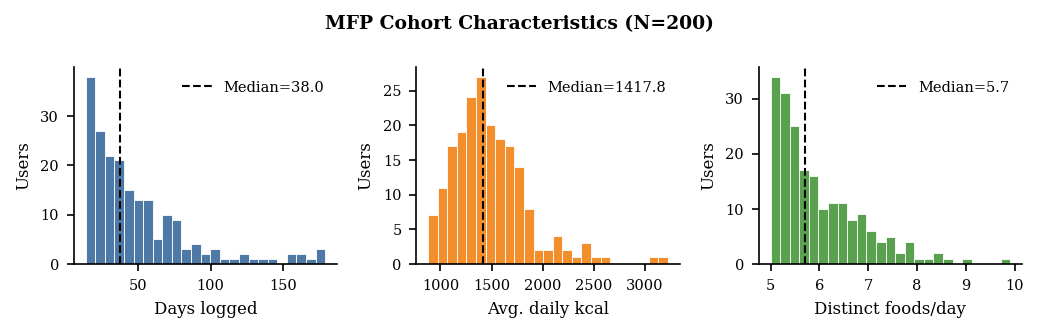

Saved cohort characterisation figure.


In [69]:
# ── Figure: Cohort characterisation (3-panel) ──────────────────────────────
cohort_stats = stats_all[stats_all["user_id"].isin(cohort)]

fig, axes = plt.subplots(1, 3, figsize=(7, 2.2))
fig.suptitle("MFP Cohort Characteristics (N=200)", fontsize=9, fontweight="bold")

panels = [
    ("n_days",        "Days logged",         "#4e79a7"),
    ("avg_calories",  "Avg. daily kcal",     "#f28e2b"),
    ("foods_per_day", "Distinct foods/day",  "#59a14f"),
]

for ax, (col, label, color) in zip(axes, panels):
    vals = cohort_stats[col].dropna()
    ax.hist(vals, bins=25, color=color, edgecolor="white", linewidth=0.4)
    ax.axvline(vals.median(), color="black", linestyle="--", linewidth=1.0,
               label=f"Median={vals.median():.1f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Users")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(str(FIG_PREFIX) + "_cohort_characterisation.pdf")
plt.savefig(str(FIG_PREFIX) + "_cohort_characterisation.png")
plt.show()
print("Saved cohort characterisation figure.")

## 4. Single-User Demo
### 4a. Single-Observation Pipeline

In [70]:
# ── Select demo user: most logged days in cohort ───────────────────────────
cohort_stats_sorted = cohort_stats[cohort_stats["user_id"].isin(cohort)].sort_values(
    "n_days", ascending=False
)
DEMO_USER_ID = int(cohort_stats_sorted.iloc[0]["user_id"])
demo_n_days  = int(cohort_stats_sorted.iloc[0]["n_days"])
demo_fpd     = cohort_stats_sorted.iloc[0]["foods_per_day"]

print(f"Demo user: {DEMO_USER_ID}  ({demo_n_days} days, {demo_fpd:.1f} foods/day)")

Demo user: 4798  (179 days, 5.6 foods/day)


In [71]:
user_df_demo = mfp_df[mfp_df["user_id"] == DEMO_USER_ID]
all_dates    = sorted(user_df_demo["date"].unique())
mid          = len(all_dates) // 2
train_dates  = list(all_dates[:mid])
test_dates   = list(all_dates[mid:])

print(f"Train period: {train_dates[0]} – {train_dates[-1]}  ({len(train_dates)} days)")
print(f"Test period:  {test_dates[0]}  – {test_dates[-1]}   ({len(test_dates)} days)")

Train period: 2014-09-14 – 2014-12-11  (89 days)
Test period:  2014-12-12  – 2015-03-11   (90 days)


In [72]:
# ── Build single-obs observation vector from training data ─────────────────
x_vec, W_S, item_index, meta = build_mfp_observation_vector(
    user_df        = user_df_demo,
    similarity_index = similarity_index,
    name_to_id     = name_to_id,
    user_id        = DEMO_USER_ID,
    train_dates    = train_dates,
    K              = K_NEIGHBORS,
    verbose        = True,
)

print(f"\nAugmented item space size |F_aug|: {len(item_index)}")
print(f"Observed items:                     {len(meta['observed_items'])}")
print(f"Neighbor items:                     {len(meta['neighbor_items'])}")


MFP User 4798:  478 distinct foods, 89 training days
  Neighbors K     : 5
  Observed items  : 478
  Neighbor items  : 1252
  Augmented size n: 1730
  ! Not in similarity JSON (40): ['Triscut Roasted Garlic', 'Truffle Fries', 'Tuna', 'Turkey Breast With Cranberry Apple Stuffing', 'Turkey Burger']

  Top observed foods (avg daily servings):
    [248] Half & Half                                      0.51 servings/day
    [206] French Roast                                     0.35 servings/day
    [ 66] Brewed Coffee                                    0.22 servings/day
    [ 67] Brewed from grounds                              0.20 servings/day
    [  4] 1% Milk                                          0.19 servings/day

  Sample neighbors (highest similarity):
    [521] Cranberry juice blend, 100% juice    sim=0.818  cost=0.182
    [1229] Grilled cheese sandwich, reduced fa  sim=0.798  cost=0.202
    [1139] Ravioli, cheese-filled, with tomato  sim=0.767  cost=0.233
    [1011] Corn soup,

In [73]:
import pandas as pd
from pathlib import Path

# Load the richer CSV
src = "/home/farzin/Diet Recommendation/IEEE paper/nutrient_values.csv"
df = pd.read_csv(src, low_memory=False)

# Rename to what _load_fndds_nutrients expects
col_map = {
    "Food code":                              "food_code",
    "Energy (kcal)":                          "energy_kcal",
    "Protein (g)":                            "protein_gm",
    "Carbohydrate (g)":                       "carbohydrate_gm",
    "Sugars, total\n(g)":                     "total_sugars_gm",
    "Fiber, total dietary (g)":               "dietary_fiber_gm",
    "Total Fat (g)":                          "total_fat_gm",
    "Fatty acids, total saturated (g)":       "total_saturated_fatty_acids_gm",
    "Cholesterol (mg)":                       "cholesterol_mg",
    "Iron\n(mg)":                             "iron_mg",
    "Sodium (mg)":                            "sodium_mg",
    "Potassium (mg)":                         "potassium_mg",
    "Calcium (mg)":                           "calcium_mg",
    "Magnesium (mg)":                         "magnesium_mg",
}

df = df.rename(columns=col_map)

# Keep only the columns the code needs
keep = list(col_map.values())
keep = [c for c in keep if c in df.columns]
df = df[keep]

print(f"Columns: {list(df.columns)}")
print(f"Rows: {len(df)}")
print(df.head(2))

# Save next to your notebook
out = Path("data/usda/2017-2018/processed/nutrient_values_full.csv")
out.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out, index=False)
print(f"\nSaved to {out}")

# Update the path
NUTRIENT_CSV = out
print(f"NUTRIENT_CSV → {NUTRIENT_CSV}")

Columns: ['food_code', 'energy_kcal', 'protein_gm', 'carbohydrate_gm', 'total_sugars_gm', 'dietary_fiber_gm', 'total_fat_gm', 'total_saturated_fatty_acids_gm', 'cholesterol_mg', 'iron_mg', 'sodium_mg', 'potassium_mg', 'calcium_mg', 'magnesium_mg']
Rows: 7083
   food_code  energy_kcal  protein_gm  carbohydrate_gm  total_sugars_gm  \
0   11000000           70        1.03             6.89             6.89   
1   11100000           51        3.34             4.87             4.89   

   dietary_fiber_gm  total_fat_gm  total_saturated_fatty_acids_gm  \
0              0.00          4.38                            2.01   
1              0.00          1.99                            1.16   

   cholesterol_mg  iron_mg  sodium_mg  potassium_mg  calcium_mg  magnesium_mg  
0              14     0.03         17            51          32             3  
1               8     0.00         39           157         126            12  

Saved to data/usda/2017-2018/processed/nutrient_values_full.csv
NU

In [74]:
# Re-run crosswalk with updated NUTRIENT_CSV
nhanes_crosswalk = build_crosswalk(fndds_path=FNDDS_PATH, usda_parquet_path=USDA_PARQUET)
print(f"nhanes_crosswalk entries: {len(nhanes_crosswalk):,}")

[build_crosswalk] 7338/7338 NHANES codes matched to similarity-JSON food_id (100.0% match rate)
nhanes_crosswalk entries: 7,083


In [75]:
# Re-run constraints with updated NUTRIENT_CSV
A, b, constraint_names, directions = build_A_b_mfp(
    item_index         = item_index,
    mfp_nutrients      = meta["mfp_nutrients"],
    fndds_nutrient_csv = NUTRIENT_CSV,          # now points to the full CSV
    nhanes_crosswalk   = nhanes_crosswalk,
    x_vector           = x_vec,
    similarity_index   = similarity_index,
    verbose            = True,
)
print(f"\nA shape: {A.shape}")
print(f"Constraints: {constraint_names}")

[build_A_b_mfp] Constraint matrix: A (9, 1730),  b (9,)
  Items: 478 observed (MFP) + 1252 neighbors (USDA)
  Constraints (9):
    [ 0] Sodium (mg)            <=  2300.0   (1629/1730 non-zero)
    [ 1] Sat. Fat (g)           <=    22.0   (1631/1730 non-zero, 477 imputed from USDA)
    [ 2] Total Sugars (g)       <=   100.0   (1577/1730 non-zero, 477 imputed from USDA)
    [ 3] Cholesterol (mg)       <=   150.0   (1030/1730 non-zero, 477 imputed from USDA)
    [ 4] Total Fat (g)          <=    65.0   (1567/1730 non-zero)
    [ 5] Fiber (g)              >=    25.0   (1261/1730 non-zero)
    [ 6] Potassium (mg)         >=  4700.0   (1705/1730 non-zero, 477 imputed from USDA)
    [ 7] Calcium (mg)           >=  1200.0   (1681/1730 non-zero, 477 imputed from USDA)
    [ 8] Protein (g)            >=    46.0   (1594/1730 non-zero)

A shape: (9, 1730)
Constraints: ['Sodium (mg)', 'Sat. Fat (g)', 'Total Sugars (g)', 'Cholesterol (mg)', 'Total Fat (g)', 'Fiber (g)', 'Potassium (mg)', 'Calcium (m

In [76]:
# ── Observed intake vs DASH bounds ────────────────────────────────────────
from smgil.constraints import check_observed_intake

check_df = check_observed_intake(A, b, x_vec, constraint_names, MFP_DASH_CONSTRAINTS)
print("\nObserved intake vs DASH bounds:")
display(check_df)


Observed intake vs DASH bounds:


,Constraint,Direction,Observed,Bound,Slack (+) / Violation (-),Satisfied
0,Sodium (mg),upper,2044.33,2300.00,255.67,True
1,Sat. Fat (g),upper,29.37,22.00,-7.37,False
2,Total Sugars (g),upper,81.91,100.00,18.09,True
3,Cholesterol (mg),upper,188.54,150.00,-38.54,False
4,Total Fat (g),upper,63.88,65.00,1.12,True
5,Fiber (g),lower,12.85,25.00,-12.15,False
6,Potassium (mg),lower,2343.91,4700.00,-2356.09,False
7,Calcium (mg),lower,941.82,1200.00,-258.18,False
8,Protein (g),lower,58.17,46.00,12.17,True


In [77]:
# Monkey-patch the config before running anything
import smgil.config as _cfg
import gurobipy as gp

def _new_gurobi_env():
    e = gp.Env(empty=True)
    e.setParam("WLSACCESSID", "aee9347f-b4d4-4058-a8c2-a0c6954ea740")
    e.setParam("WLSSECRET",   "30cef1f9-9233-48a0-a138-9d092ef2ce32")
    e.setParam("LICENSEID",   862033)
    e.start()
    return e

_cfg.make_gurobi_env = _new_gurobi_env

# Also patch it in solver since it imports directly
import smgil.solver as _slv
_slv.make_gurobi_env = _new_gurobi_env

print("Gurobi env patched.")

Gurobi env patched.


In [78]:
# ── Run single-obs SGIO tradeoff ───────────────────────────────────────────
W_S_tuned = tune_weights_mfp(W_S, meta)
X_obs     = x_vec.reshape(1, -1)

tradeoff_single = run_smgil_tradeoff(
    A, b, X_obs, W_S_tuned, item_index, meta,
    constraint_names = constraint_names,
    max_iterations   = MAX_ITER,
    cost_threshold   = COST_THRESHOLD,
)

print_full_report(
    x_vec, A, b, item_index, meta,
    constraint_names, directions, tradeoff_single, DEMO_USER_ID,
)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu



-- Iteration 1 ────────────────────────────────────────
  Tight constraints : ['Total Sugars (g)']
  Weighted distance : 0.0725  (marginal: +0.0725)
  Food swaps:
    ▲ Beets, baby food, strained                        0.0 ->    7.6 g  W=0.000  <- NEW ITEM
    ▲ Ravioli, cheese-filled, with tomato sauce         0.0 ->    2.6 g  W=0.000  <- NEW ITEM
    ▲ Caramel Macchiato (Instant)                       0.0 ->    0.1 g  W=2.000
    ▲ 1 %                                               0.1 ->    0.1 g  W=2.000
    ▲ 1% Milk                                           0.2 ->    0.2 g  W=2.000
    ▲ Animal Style Fries                                0.0 ->    0.0 g  W=2.000
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu

-- Iteration 2 ────────────────────────────────────────
  Tight constraints : ['Sat. Fat (g)', 'Total Sugars (g)']
  Weighted distance : 0.0723  (mar

In [79]:
# ── Summary table for this user ────────────────────────────────────────────
df_single_demo = summary_table(tradeoff_single)
print(f"\nSingle-obs demo summary ({DEMO_USER_ID}):")
display(df_single_demo)


Single-obs demo summary (4798):


,Iteration,Tight Constraints,dD (marginal),Food Code,Food Name,Observed (g),Recommended (g),Delta (g),Action,W_S (switch cost),New Item?
0,1,Total Sugars (g),0.07,6294,"Beets, baby food, strained",0.00,7.60,7.60,ADD_NEW,0.00,True
1,1,Total Sugars (g),0.07,4675,"Ravioli, cheese-filled, with tomato sauce",0.00,2.60,2.60,ADD_NEW,0.00,True
2,1,Total Sugars (g),0.07,1099698,Caramel Macchiato (Instant),0.00,0.10,0.10,increase,2.00,False
3,1,Total Sugars (g),0.07,1004389,1 %,0.10,0.10,0.00,increase,2.00,False
4,1,Total Sugars (g),0.07,1006084,1% Milk,0.20,0.20,0.00,increase,2.00,False
...,...,...,...,...,...,...,...,...,...,...,...
458,4,"Sodium (mg), Sat. Fat (g), Total Sugars (g), Choles...",-0.00,1541621,Sweet Poppy Seed Dressing,0.00,0.00,-0.00,reduce,2.00,False
459,4,"Sodium (mg), Sat. Fat (g), Total Sugars (g), Choles...",-0.00,1544504,Swimming Rama,0.00,0.00,-0.00,reduce,2.00,False
460,4,"Sodium (mg), Sat. Fat (g), Total Sugars (g), Choles...",-0.00,1545245,Syrups,0.00,0.00,-0.00,reduce,2.00,False
461,4,"Sodium (mg), Sat. Fat (g), Total Sugars (g), Choles...",-0.00,1556547,Tiramisu,0.00,0.00,-0.00,reduce,2.00,False


### 4b. Multi-Observation Extension (demo)

In [80]:
# ── Select user with more days for multi-obs demo ─────────────────────────
# Use a user with ≥30 days for richer per-day variation
mo_candidates = cohort_stats_sorted[cohort_stats_sorted["n_days"] >= 30]
MO_USER_ID    = int(mo_candidates.iloc[0]["user_id"]) if not mo_candidates.empty else DEMO_USER_ID
print(f"Multi-obs demo user: {MO_USER_ID}  "
      f"({int(cohort_stats_sorted[cohort_stats_sorted['user_id']==MO_USER_ID]['n_days'].values[0])} days)")

Multi-obs demo user: 4798  (179 days)


In [81]:
user_df_mo = mfp_df[mfp_df["user_id"] == MO_USER_ID]

# ── Build daily matrix ────────────────────────────────────────────────────
X_daily, x_vec_mo, W_S_mo, item_index_mo, meta_mo = build_mfp_daily_matrix(
    user_df          = user_df_mo,
    similarity_index = similarity_index,
    name_to_id       = name_to_id,
    user_id          = MO_USER_ID,
    K                = K_NEIGHBORS,
    verbose          = True,
)

K_days = X_daily.shape[0]
print(f"\nDaily matrix: {X_daily.shape}  ({K_days} days × {X_daily.shape[1]} items)")


MFP User 4798 — Multi-Observation Matrix
  Training days   : 179
  Item space n    : 2788
  X_daily shape   : (179, 2788)
  Items/day       : 8.9 (min=2, max=19)
  Servings/day    : 9.0 (min=2, max=19)


Daily matrix: (179, 2788)  (179 days × 2788 items)


In [82]:
A_mo, b_mo, cnames_mo, dirs_mo = build_A_b_mfp(
    item_index       = item_index_mo,
    mfp_nutrients    = meta_mo["mfp_nutrients"],
    fndds_nutrient_csv = NUTRIENT_CSV,
    nhanes_crosswalk = nhanes_crosswalk,
    x_vector         = x_vec_mo,
    similarity_index = similarity_index,
    verbose          = False,
)

W_S_mo_tuned   = tune_weights(W_S_mo, meta_mo)
X_obs_mo       = x_vec_mo.reshape(1, -1)

# Single-obs baseline for comparison
tradeoff_mo_single = run_smgil_tradeoff(
    A_mo, b_mo, X_obs_mo, W_S_mo_tuned, item_index_mo, meta_mo,
    constraint_names = cnames_mo,
    max_iterations   = MAX_ITER,
    cost_threshold   = COST_THRESHOLD,
    verbose          = False,
)

# Multi-obs
tradeoff_mo_multi = run_smgil_tradeoff_multi_obs(
    A_mo, b_mo, X_daily, W_S_mo_tuned, item_index_mo, meta_mo,
    constraint_names = cnames_mo,
    max_iterations   = MAX_ITER,
    cost_threshold   = COST_THRESHOLD,
)

print(f"Single-obs iterations completed: {len(tradeoff_mo_single)}")
print(f"Multi-obs  iterations completed: {len(tradeoff_mo_multi)}")

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu

Interrupt request received
  S-MGIL-MultiObs status: 11 (infeasible or unbounded)
  Iteration 1: infeasible -- stopping.
Single-o

In [ ]:
# ── Multi-obs comparison table ─────────────────────────────────────────────
signs_mo = np.array([1 if d == "upper" else -1 for d in dirs_mo])
scale_mo = np.abs(b_mo)
scale_mo[scale_mo < 1e-6] = 1.0

n_compare = min(len(tradeoff_mo_single), len(tradeoff_mo_multi))
mo_rows   = []

for i in range(n_compare):
    rs = tradeoff_mo_single[i]
    rm = tradeoff_mo_multi[i]
    for method, r in [("single", rs), ("multi", rm)]:
        diff       = x_vec_mo - r["z"]
        d_food     = float(np.linalg.norm(diff))
        d_foodW    = float(np.sqrt(np.dot(W_S_mo * diff, diff)))
        tight      = ", ".join(r["tight_constraints"])
        mo_rows.append({
            "iter":   r["iteration"],
            "method": method,
            "d_food": round(d_food, 4),
            "d_foodW": round(d_foodW, 4),
            "tight":  tight,
        })

mo_compare_df = pd.DataFrame(mo_rows)
print(f"\nSingle-obs vs Multi-obs comparison (user={MO_USER_ID}):")
display(mo_compare_df)

In [ ]:
# ── Per-day spread in multi-obs recommendations ────────────────────────────
if tradeoff_mo_multi:
    last      = tradeoff_mo_multi[-1]
    Z_all     = last["z_all"]          # shape: (K_days, n_items)
    Z_mean    = last["z"]
    spread    = np.std(Z_all, axis=0)
    active    = np.where(Z_mean > 0.01)[0]

    idx_to_code = {v: k for k, v in item_index_mo.items()}
    name_map    = {}
    for item in meta_mo["observed_items"] + meta_mo["neighbor_items"]:
        name_map[item["food_code"]] = item["food_name"]

    spread_rows = []
    for idx in sorted(active, key=lambda i: spread[i], reverse=True)[:15]:
        code  = idx_to_code.get(idx)
        fname = name_map.get(code, str(code))
        vals  = Z_all[:, idx]
        spread_rows.append({
            "food": fname[:50],
            "mean_srv": round(Z_mean[idx], 3),
            "std_srv":  round(vals.std(), 3),
            "min_srv":  round(vals.min(), 3),
            "max_srv":  round(vals.max(), 3),
        })

    spread_df = pd.DataFrame(spread_rows)
    print("Per-day recommendation variability (last iteration, top 15 by std):")
    display(spread_df)

## 5. Cohort Temporal-Split Validation (N=200)

In [83]:
# ── Check if pre-computed results exist ───────────────────────────────────
if COHORT_CSV.exists():
    print(f"Pre-computed results found at {COHORT_CSV}. Loading ...")
    df_results = pd.read_csv(COHORT_CSV)
    print(f"  Loaded {len(df_results)} rows.")
    _run_cohort = False
else:
    print("No pre-computed results. Will run cohort validation.")
    _run_cohort = True

No pre-computed results. Will run cohort validation.


In [119]:
def tune_weights_mfp(W_S, meta,
                     obs_penalty_scale=2.0,
                     min_sim_threshold=0.1):
    W = W_S.copy()
    for item in meta["observed_items"]:
        W[item["index"]] *= obs_penalty_scale
    for item in meta["neighbor_items"]:
        idx = item["index"]
        sim = item["similarity_score"]
        if sim < min_sim_threshold:
            W[idx] = 1e6
        else:
            W[idx] = max(1e-6, W_S[idx] * (1.0 - sim))
    return W


In [120]:
%%time

if _run_cohort:
    records = []
    failed  = 0

    for i, uid in enumerate(cohort):
        print(f"[{i+1:3d}/{len(cohort)}] user={uid}", end=" ... ")
        try:
            user_food_df = mfp_df[mfp_df["user_id"] == uid]
            all_dates    = sorted(user_food_df["date"].unique())
            n_dates      = len(all_dates)

            if n_dates < MIN_DAYS:
                print(f"only {n_dates} days — skip")
                failed += 1
                continue

            # ── Temporal split ─────────────────────────────────────────────
            mid          = n_dates // 2
            train_dates  = list(all_dates[:mid])
            test_dates   = list(all_dates[mid:])
            n_train_days = len(train_dates)
            n_test_days  = len(test_dates)

            # ── Observation vector (train) ─────────────────────────────────
            x_vector, W_S, item_index, meta = build_mfp_observation_vector(
                user_df          = user_food_df,
                similarity_index = similarity_index,
                name_to_id       = name_to_id,
                user_id          = uid,
                train_dates      = train_dates,
                K                = K_NEIGHBORS,
                verbose          = False,
            )

            # ── DASH constraints ──────────────────────────────────────────
            A, b, constraint_names, directions = build_A_b_mfp(
                item_index         = item_index,
                mfp_nutrients      = meta["mfp_nutrients"],
                fndds_nutrient_csv = NUTRIENT_CSV,
                nhanes_crosswalk   = nhanes_crosswalk,
                x_vector           = x_vector,
                similarity_index   = similarity_index,
                verbose            = False,
            )

            W_S_tuned = tune_weights_mfp(W_S, meta)
            X_obs     = x_vector.reshape(1, -1)

            signs = np.array([1 if d == "upper" else -1 for d in directions])
            scale = np.abs(b)
            scale[scale < 1e-6] = 1.0
            n1    = signs * (A @ x_vector)   # training-period nutrients

            # ── Test-period projection ────────────────────────────────────
            test_food_df = user_food_df[user_food_df["date"].isin(test_dates)]
            x_test, coverage = project_mfp_holdout(
                test_food_df, item_index, name_to_id, similarity_index,
            )

            # ── Test-period nutrients from day-level table ─────────────────
            test_user_days = users_df[
                (users_df["user_id"] == uid) &
                (users_df["date"].isin(test_dates))
            ]
            n2_values = []
            for mfp_col in MFP_NUTRIENT_COLS:
                if mfp_col in test_user_days.columns:
                    n2_values.append(test_user_days[mfp_col].sum() / n_test_days)
                else:
                    n2_values.append(0.0)
            n2 = np.array(n2_values, dtype=float)

            # ── Natural distances ─────────────────────────────────────────
            d_nut_nat    = float(np.linalg.norm((n1 - n2) / scale))
            d_food_nat   = float(np.linalg.norm(x_vector - x_test))
            d_food_w_nat = float(np.sqrt(np.dot(W_S * (x_vector - x_test), (x_vector - x_test))))

            # ── S-MGIL tradeoff ───────────────────────────────────────────
            tradeoff = run_smgil_tradeoff(
                A, b, X_obs, W_S_tuned, item_index, meta,
                constraint_names = constraint_names,
                max_iterations   = MAX_ITER,
                cost_threshold   = COST_THRESHOLD,
                verbose          = False,
            )

            rec = {
                "uid":             uid,
                "n_items":         len(item_index),
                "n_train_days":    n_train_days,
                "n_test_days":     n_test_days,
                "coverage_test":   round(coverage, 4),
                "n_iter":          len(tradeoff),
                "d_nut_natural":   d_nut_nat,
                "d_food_natural":  d_food_nat,
                "d_foodW_natural": d_food_w_nat,
            }
            for r in tradeoff:
                ell  = r["iteration"]
                dists = compute_distances(x_vector, r["z"], W_S, A, b, n1, signs, scale)
                rec[f"d_nut_r{ell}"]   = dists["d_nut"]
                rec[f"d_food_r{ell}"]  = dists["d_food"]
                rec[f"d_foodW_r{ell}"] = dists["d_foodW"]
                rec[f"tight_r{ell}"]   = ", ".join(r["tight_constraints"])

            records.append(rec)
            print(f"OK  (r={len(tradeoff)}, cov={coverage:.2f}, n={len(item_index)})")

        except Exception as e:
            print(f"FAILED: {e}")
            failed += 1

    df_results = pd.DataFrame(records)
    df_results.to_csv(COHORT_CSV, index=False)
    print(f"\nDone. {len(df_results)} succeeded, {failed} failed.")
    print(df_results.describe().round(4))

[  1/200] user=6396 ... Set parameter WLSAccessID
Set parameter WLSSecret


Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
OK  (r=4, cov=0.45, n=528)
[  2/200] user=4652 ... Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-comme

## 6. Statistical Analysis

In [121]:
# ── Amenability classification ─────────────────────────────────────────────
# A user is amenable if they have at least r=1 results
amenable_mask      = df_results["d_nut_r1"].notna()
n_amenable         = amenable_mask.sum()
n_non_amenable     = (~amenable_mask).sum()
n_total            = len(df_results)
pct_non_amenable   = 100 * n_non_amenable / n_total

print(f"Total participants in results: {n_total}")
print(f"  Amenable (≥1 iteration):     {n_amenable} ({100*n_amenable/n_total:.0f}%)")
print(f"  Non-amenable:                {n_non_amenable} ({pct_non_amenable:.0f}%)")

df_amenable = df_results[amenable_mask].copy()

Total participants in results: 200
  Amenable (≥1 iteration):     200 (100%)
  Non-amenable:                0 (0%)


In [122]:
# ── Coverage statistics ────────────────────────────────────────────────────
cov = df_results["coverage_test"]
print(f"Test-period projection coverage:")
print(f"  Mean:   {cov.mean():.3f}")
print(f"  Median: {cov.median():.3f}")
print(f"  ≥80%:   {(cov >= 0.80).mean()*100:.0f}% of users")

Test-period projection coverage:
  Mean:   0.481
  Median: 0.477
  ≥80%:   0% of users


In [123]:
# ── Wilcoxon signed-rank tests ─────────────────────────────────────────────
# H0: rec distance ≥ natural distance
# H1: rec distance < natural distance (one-sided, alternative='less')

print("=" * 72)
print("  WILCOXON SIGNED-RANK TEST")
print("  H0: d_rec ≥ d_nat   |   H1: d_rec < d_nat  (one-sided)")
print("=" * 72)

wilcoxon_results = {}

for metric, label in [
    ("d_nut",   "Nutrient space (normalised L2)"),
    ("d_food",  "Food space (servings)"),
    ("d_foodW", "Food space weighted"),
]:
    nat_col = f"{metric}_natural"
    print(f"\n  -- {label} --")
    if nat_col not in df_amenable.columns:
        print(f"  Column {nat_col} not found — skipping.")
        continue

    for r in [1, 2, 3, 4]:
        rec_col = f"{metric}_r{r}"
        if rec_col not in df_amenable.columns:
            continue
        merged = df_amenable[[nat_col, rec_col]].dropna()
        if len(merged) < 10:
            print(f"  r={r}: n={len(merged)} — too few, skip.")
            continue

        W_stat, p_val = stats.wilcoxon(
            merged[rec_col], merged[nat_col], alternative="less"
        )
        med_rec = merged[rec_col].median()
        med_nat = merged[nat_col].median()
        mean_rec = merged[rec_col].mean()
        n        = len(merged)

        stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        print(f"  r={r} (n={n}):  median rec={med_rec:.3f}  nat={med_nat:.3f}  "
              f"W={W_stat:.0f}  p={p_val:.3e}  {stars}")

        wilcoxon_results[(metric, r)] = {
            "n": n, "W": W_stat, "p": p_val,
            "med_rec": med_rec, "med_nat": med_nat,
            "mean_rec": mean_rec, "stars": stars,
        }

print("\nDone.")

  WILCOXON SIGNED-RANK TEST
  H0: d_rec ≥ d_nat   |   H1: d_rec < d_nat  (one-sided)

  -- Nutrient space (normalised L2) --
  r=1 (n=200):  median rec=1.637  nat=3.092  W=153  p=7.070e-34  ***
  r=2 (n=200):  median rec=1.637  nat=3.092  W=153  p=7.070e-34  ***
  r=3 (n=200):  median rec=1.650  nat=3.092  W=153  p=7.070e-34  ***
  r=4 (n=200):  median rec=1.651  nat=3.092  W=153  p=7.070e-34  ***

  -- Food space (servings) --
  r=1 (n=200):  median rec=0.643  nat=1.195  W=1085  p=3.758e-28  ***
  r=2 (n=200):  median rec=0.643  nat=1.195  W=1085  p=3.758e-28  ***
  r=3 (n=200):  median rec=0.645  nat=1.195  W=1085  p=3.758e-28  ***
  r=4 (n=200):  median rec=0.647  nat=1.195  W=1084  p=3.708e-28  ***

  -- Food space weighted --
  r=1 (n=200):  median rec=0.552  nat=1.177  W=351  p=1.295e-32  ***
  r=2 (n=200):  median rec=0.552  nat=1.177  W=350  p=1.277e-32  ***
  r=3 (n=200):  median rec=0.553  nat=1.177  W=349  p=1.258e-32  ***
  r=4 (n=200):  median rec=0.553  nat=1.177  W=352  

In [124]:
# ── Fraction below natural median by iteration ─────────────────────────────
nat_med_nut  = df_amenable["d_nut_natural"].median()
nat_med_food = df_amenable["d_food_natural"].median()

print(f"Cohort natural medians (amenable, n={len(df_amenable)}):")
print(f"  Nutrient space: {nat_med_nut:.3f}")
print(f"  Food space:     {nat_med_food:.3f}")

print("\nFraction below natural median:")
print(f"  {'Iter':<6}  {'Nutrient':<12}  {'Food':<12}  {'n_nut':<8}  {'n_food':<8}")
for r in [1, 2, 3, 4]:
    nc = f"d_nut_r{r}"
    fc = f"d_food_r{r}"
    if nc in df_amenable.columns and fc in df_amenable.columns:
        nn   = df_amenable[nc].notna().sum()
        nf   = df_amenable[fc].notna().sum()
        frac_nut  = (df_amenable[nc].dropna() < nat_med_nut).mean()
        frac_food = (df_amenable[fc].dropna() < nat_med_food).mean()
        print(f"  r={r}    {frac_nut*100:5.0f}%       {frac_food*100:5.0f}%       {nn:<8}  {nf:<8}")

Cohort natural medians (amenable, n=200):
  Nutrient space: 3.092
  Food space:     1.195

Fraction below natural median:
  Iter    Nutrient      Food          n_nut     n_food  
  r=1       92%          91%       200       200     
  r=2       92%          91%       200       200     
  r=3       92%          91%       200       200     
  r=4       92%          91%       200       200     


## 7. Paper-Ready Figures
### 7a. Main Validation Figure (6-panel, mirrors NHANES Fig. 1)

In [125]:
def make_validation_figure(df, metric_base, metric_label, unit_label,
                           nat_med, nat_col, food_cap=None,
                           fig_title="MFP Temporal-Split Validation"):
    """6-panel validation figure mirroring the NHANES figure structure."""

    iter_cols  = [c for c in [f"{metric_base}_r{r}" for r in [1,2,3,4]]
                  if c in df.columns]
    r_vals     = [int(c.split("_r")[1]) for c in iter_cols]

    fig = plt.figure(figsize=(7.16, 7.5))  # IEEE double-column width
    gs  = gridspec.GridSpec(
        3, 3,
        figure=fig,
        hspace=0.45, wspace=0.35,
        height_ratios=[1, 1, 0.9],
    )

    ax_scatter = fig.add_subplot(gs[0, 0])
    ax_box     = fig.add_subplot(gs[0, 1:3])
    ax_food    = fig.add_subplot(gs[1, 0:2])
    ax_frac    = fig.add_subplot(gs[1, 2])
    ax_ratio_n = fig.add_subplot(gs[2, 0])
    ax_ratio_f = fig.add_subplot(gs[2, 1])
    ax_iter_n  = fig.add_subplot(gs[2, 2])

    # ── Panel 1: Scatter r=1 vs natural ────────────────────────────────────
    r1_col = f"{metric_base}_r1"
    if r1_col in df.columns:
        sub = df[[nat_col, r1_col]].dropna()
        nat_vals = sub[nat_col].values
        rec_vals = sub[r1_col].values
        if food_cap is not None:
            nat_vals = np.clip(nat_vals, 0, food_cap)
            rec_vals = np.clip(rec_vals, 0, food_cap)
        lim_max = max(nat_vals.max(), rec_vals.max()) * 1.05
        ax_scatter.scatter(nat_vals, rec_vals, s=12, alpha=0.55,
                           color=ITER_COLORS[0], edgecolors="none")
        ax_scatter.plot([0, lim_max], [0, lim_max], "--", color="#555",
                        linewidth=0.8, zorder=5)
        ax_scatter.set_xlabel(f"Natural ({unit_label})")
        ax_scatter.set_ylabel(f"Rec r=1 ({unit_label})")
        ax_scatter.set_title("Panel 1: Scatter (r=1 vs natural)")
        ax_scatter.spines[["top", "right"]].set_visible(False)
        n_below = (sub[r1_col] < sub[nat_col]).sum()
        ax_scatter.text(0.05, 0.92, f"{100*n_below/len(sub):.0f}% below diagonal",
                        transform=ax_scatter.transAxes, fontsize=6, color="#333")

    # ── Panel 2: Box plots by iteration ────────────────────────────────────
    box_data = [df[nat_col].dropna().values] + \
               [df[c].dropna().values for c in iter_cols]
    if food_cap is not None:
        box_data = [np.clip(d, 0, food_cap) for d in box_data]
    bp = ax_box.boxplot(box_data,
                         patch_artist=True,
                         medianprops=dict(color="black", linewidth=1.2),
                         flierprops=dict(marker=".", markersize=2, alpha=0.4),
                         whiskerprops=dict(linewidth=0.7),
                         capprops=dict(linewidth=0.7))
    colors_box = [NAT_COLOR] + ITER_COLORS[:len(iter_cols)]
    for patch, color in zip(bp["boxes"], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    labels_box = ["Natural"] + [f"r={r}" for r in r_vals]
    ax_box.set_xticklabels(labels_box, fontsize=6.5)
    ax_box.axhline(nat_med, color=NAT_COLOR, linestyle=":", linewidth=0.9)
    ax_box.set_ylabel(f"{metric_label} ({unit_label})")
    ax_box.set_title("Panel 2: Distance by iteration")
    ax_box.spines[["top", "right"]].set_visible(False)

    # ── Panel 3: Food-space distances by iteration ─────────────────────────
    food_nat_col = "d_food_natural"
    food_iter_cols = [c for c in [f"d_food_r{r}" for r in [1,2,3,4]]
                      if c in df.columns]
    if food_nat_col in df.columns:
        food_nat_med = df[food_nat_col].median()
        food_data = [df[food_nat_col].dropna().values] + \
                    [df[c].dropna().values for c in food_iter_cols]
        if food_cap is not None:
            food_data = [np.clip(d, 0, food_cap) for d in food_data]
        bp2 = ax_food.boxplot(food_data,
                               patch_artist=True,
                               medianprops=dict(color="black", linewidth=1.2),
                               flierprops=dict(marker=".", markersize=2, alpha=0.4),
                               whiskerprops=dict(linewidth=0.7),
                               capprops=dict(linewidth=0.7))
        fc_colors = [NAT_COLOR] + ITER_COLORS[:len(food_iter_cols)]
        for patch, color in zip(bp2["boxes"], fc_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.65)
        f_labels = ["Natural"] + [f"r={r}" for r in [1,2,3,4][:len(food_iter_cols)]]
        ax_food.set_xticklabels(f_labels, fontsize=6.5)
        ax_food.axhline(food_nat_med, color=NAT_COLOR, linestyle=":", linewidth=0.9)
        ax_food.set_ylabel("Food distance (servings)")
        ax_food.set_title("Panel 3: Food-space distance by iteration")
        ax_food.spines[["top", "right"]].set_visible(False)

    # ── Panel 4: Fraction below natural median ─────────────────────────────
    frac_nut  = []
    frac_food = []
    for r in r_vals:
        nc = f"{metric_base}_r{r}"
        fc = f"d_food_r{r}"
        if nc in df.columns:
            frac_nut.append((df[nc].dropna() < nat_med).mean() * 100)
        if fc in df.columns and food_nat_col in df.columns:
            food_nat_m = df[food_nat_col].median()
            frac_food.append((df[fc].dropna() < food_nat_m).mean() * 100)
    ax_frac.plot(r_vals[:len(frac_nut)],  frac_nut,  "o-", color="#1f77b4",
                 linewidth=1.2, markersize=5, label="Nutrient")
    ax_frac.plot(r_vals[:len(frac_food)], frac_food, "s-", color="#2ca02c",
                 linewidth=1.2, markersize=5, label="Food")
    ax_frac.set_xticks(r_vals)
    ax_frac.set_xlabel("Iteration r")
    ax_frac.set_ylabel("% below natural median")
    ax_frac.set_title("Panel 4: % below nat. median")
    ax_frac.legend(frameon=False)
    ax_frac.set_ylim(0, 105)
    ax_frac.spines[["top", "right"]].set_visible(False)

    # ── Panel 5a: Ratio distribution (nutrient) ────────────────────────────
    if r1_col in df.columns:
        sub2     = df[[nat_col, r1_col]].dropna()
        ratio_n  = (sub2[r1_col] / sub2[nat_col].replace(0, np.nan)).dropna()
        ratio_n  = ratio_n[np.isfinite(ratio_n) & (ratio_n < 5)]
        ax_ratio_n.hist(ratio_n, bins=30, color=ITER_COLORS[0], edgecolor="white",
                        linewidth=0.3, alpha=0.85)
        ax_ratio_n.axvline(1.0, color="black", linestyle="--", linewidth=0.9)
        ax_ratio_n.axvline(ratio_n.median(), color=ITER_COLORS[0], linestyle="-",
                           linewidth=1.0, alpha=0.8)
        pct_below = (ratio_n < 1.0).mean() * 100
        ax_ratio_n.set_xlabel("d_rec / d_nat (nutrient)")
        ax_ratio_n.set_ylabel("Users")
        ax_ratio_n.set_title(f"Panel 5a: Ratio dist. (r=1)\n{pct_below:.0f}% < 1.0")
        ax_ratio_n.spines[["top", "right"]].set_visible(False)

    # ── Panel 5b: Ratio distribution (food) ───────────────────────────────
    if "d_food_r1" in df.columns and food_nat_col in df.columns:
        sub3    = df[[food_nat_col, "d_food_r1"]].dropna()
        ratio_f = (sub3["d_food_r1"] / sub3[food_nat_col].replace(0, np.nan)).dropna()
        ratio_f = ratio_f[np.isfinite(ratio_f) & (ratio_f < 5)]
        ax_ratio_f.hist(ratio_f, bins=30, color="#2ca02c", edgecolor="white",
                        linewidth=0.3, alpha=0.85)
        ax_ratio_f.axvline(1.0, color="black", linestyle="--", linewidth=0.9)
        ax_ratio_f.axvline(ratio_f.median(), color="#2ca02c", linestyle="-",
                           linewidth=1.0, alpha=0.8)
        pct_below_f = (ratio_f < 1.0).mean() * 100
        ax_ratio_f.set_xlabel("d_rec / d_nat (food)")
        ax_ratio_f.set_ylabel("Users")
        ax_ratio_f.set_title(f"Panel 5b: Ratio dist. (r=1)\n{pct_below_f:.0f}% < 1.0")
        ax_ratio_f.spines[["top", "right"]].set_visible(False)

    # ── Panel 6: Iteration count distribution ─────────────────────────────
    if "n_iter" in df.columns:
        iter_counts = df["n_iter"].value_counts().sort_index()
        ax_iter_n.bar(iter_counts.index, iter_counts.values,
                      color="#9467bd", edgecolor="white", linewidth=0.4)
        ax_iter_n.set_xlabel("Iterations completed")
        ax_iter_n.set_ylabel("Users")
        ax_iter_n.set_title("Panel 6: Tradeoff path length")
        ax_iter_n.spines[["top", "right"]].set_visible(False)

    fig.suptitle(fig_title, fontsize=10, fontweight="bold", y=1.01)
    return fig


print("Figure function defined.")

Figure function defined.


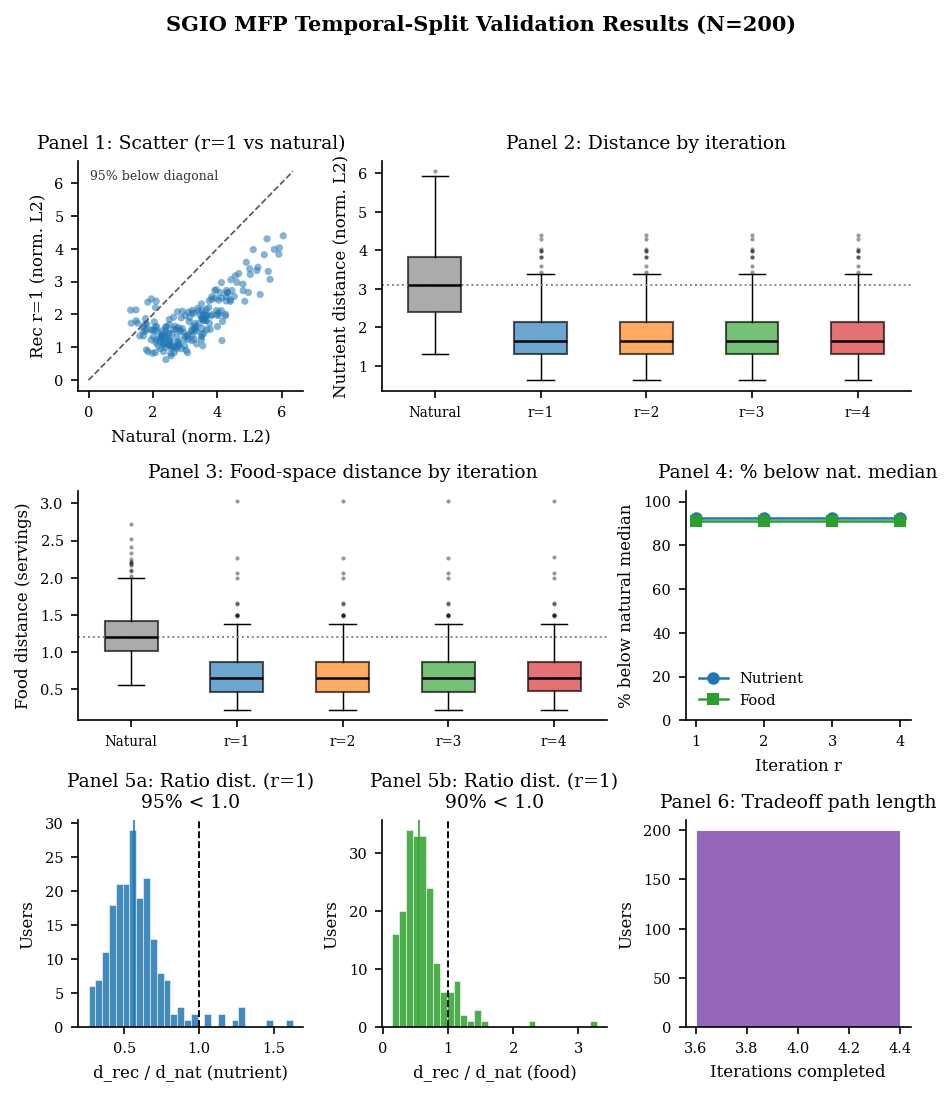

Saved to outputs/smgil_mfp_validation_figures.{pdf,png}


In [126]:
# ── Generate main validation figure ───────────────────────────────────────
nat_med_nut = df_amenable["d_nut_natural"].median()

fig_main = make_validation_figure(
    df          = df_amenable,
    metric_base = "d_nut",
    metric_label= "Nutrient distance",
    unit_label  = "norm. L2",
    nat_med     = nat_med_nut,
    nat_col     = "d_nut_natural",
    food_cap    = None,          # servings; no cap needed (unlike grams)
    fig_title   = "SGIO MFP Temporal-Split Validation Results (N=200)",
)

fig_main.savefig(str(FIG_PREFIX) + "_figures.pdf")
fig_main.savefig(str(FIG_PREFIX) + "_figures.png")
plt.show()
print(f"Saved to {FIG_PREFIX}_figures.{{pdf,png}}")

### 7b. Multi-Obs Comparison Figure

In [91]:
# ── Run multi-obs over a subset of cohort for comparison ──────────────────
# NOTE: Multi-obs is more expensive; run on the subset with ≥30 days

# Identify subset of cohort with enough days for meaningful multi-obs
mo_subset_ids = [
    uid for uid in cohort
    if cohort_stats[cohort_stats["user_id"] == uid]["n_days"].values[0] >= 30
]
N_MO_SUBSET = min(50, len(mo_subset_ids))
print(f"Multi-obs subset (≥30 days): {len(mo_subset_ids)} users")
print(f"Running on first {N_MO_SUBSET} ...")

mo_records = []
mo_failed  = 0

for i, uid in enumerate(mo_subset_ids[:N_MO_SUBSET]):
    print(f"[{i+1:2d}/{N_MO_SUBSET}] user={uid}", end=" ... ")
    try:
        user_food_df = mfp_df[mfp_df["user_id"] == uid]
        all_dates    = sorted(user_food_df["date"].unique())

        # Use all dates for multi-obs (not temporal split — comparison within same period)
        X_daily, x_vec_u, W_S_u, item_idx_u, meta_u = build_mfp_daily_matrix(
            user_df=user_food_df, similarity_index=similarity_index,
            name_to_id=name_to_id, user_id=uid, K=K_NEIGHBORS, verbose=False,
        )
        K_days_u = X_daily.shape[0]

        A_u, b_u, cnames_u, dirs_u = build_A_b_mfp(
            item_index=item_idx_u, mfp_nutrients=meta_u["mfp_nutrients"],
            fndds_nutrient_csv=NUTRIENT_CSV, nhanes_crosswalk=nhanes_crosswalk,
            x_vector=x_vec_u, similarity_index=similarity_index, verbose=False,
        )

        W_S_u_tuned = tune_weights(W_S_u, meta_u)
        X_obs_u     = x_vec_u.reshape(1, -1)

        # Single-obs
        trd_s = run_smgil_tradeoff(
            A_u, b_u, X_obs_u, W_S_u_tuned, item_idx_u, meta_u,
            constraint_names=cnames_u, max_iterations=MAX_ITER,
            cost_threshold=COST_THRESHOLD, verbose=False,
        )

        # Multi-obs
        trd_m = run_smgil_tradeoff_multi_obs(
            A_u, b_u, X_daily, W_S_u_tuned, item_idx_u, meta_u,
            constraint_names=cnames_u, max_iterations=MAX_ITER,
            cost_threshold=COST_THRESHOLD,
        )

        for r_s, r_m in zip(trd_s, trd_m):
            ell = r_s["iteration"]
            diff_s = x_vec_u - r_s["z"]
            diff_m = x_vec_u - r_m["z"]
            mo_records.append({
                "uid":        uid,
                "K_days":     K_days_u,
                "iter":       ell,
                "d_foodW_single": float(np.sqrt(np.dot(W_S_u * diff_s, diff_s))),
                "d_foodW_multi":  float(np.sqrt(np.dot(W_S_u * diff_m, diff_m))),
                "tight_single":   ", ".join(r_s["tight_constraints"]),
                "tight_multi":    ", ".join(r_m["tight_constraints"]),
            })

        print(f"OK (K={K_days_u}, r_s={len(trd_s)}, r_m={len(trd_m)})")

    except Exception as e:
        print(f"FAILED: {e}")
        mo_failed += 1

df_mo = pd.DataFrame(mo_records)
print(f"\nMulti-obs records: {len(df_mo)}  failures: {mo_failed}")

Multi-obs subset (≥30 days): 128 users
Running on first 50 ...
[ 1/50] user=6396 ... Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu


KeyboardInterrupt: 

In [ ]:
# ── Multi-obs comparison figure ────────────────────────────────────────────
if not df_mo.empty:
    fig_mo, axes_mo = plt.subplots(1, 2, figsize=(6, 2.8))
    fig_mo.suptitle("Single-Obs vs Multi-Obs SGIO (MFP subset, ≥30 days)",
                    fontsize=9, fontweight="bold")

    for ax, r_val, color in zip(axes_mo, [1, 4], [ITER_COLORS[0], ITER_COLORS[3]]):
        sub_mo = df_mo[df_mo["iter"] == r_val]
        if sub_mo.empty:
            ax.text(0.5, 0.5, f"r={r_val}: no data",
                    transform=ax.transAxes, ha="center")
            continue
        diff = sub_mo["d_foodW_single"] - sub_mo["d_foodW_multi"]
        ax.hist(diff, bins=20, color=color, edgecolor="white", linewidth=0.3, alpha=0.8)
        ax.axvline(0, color="black", linestyle="--", linewidth=0.9)
        ax.axvline(diff.median(), color=color, linestyle="-", linewidth=1.2,
                   label=f"Median={diff.median():.3f}")
        pct_mo_better = (diff > 0).mean() * 100
        ax.set_xlabel("d_foodW(single) − d_foodW(multi)")
        ax.set_ylabel("Users")
        ax.set_title(f"r={r_val}: multi-obs smaller in {pct_mo_better:.0f}%")
        ax.legend(frameon=False)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    fig_mo.savefig(str(FIG_PREFIX) + "_multi_obs_comparison.pdf")
    fig_mo.savefig(str(FIG_PREFIX) + "_multi_obs_comparison.png")
    plt.show()
    print(f"Saved multi-obs comparison figure.")

## 8. Paper Tables
### 8a. Main Results Table (LaTeX)

In [92]:
def sig_stars(p):
    if   p < 0.001: return "$^{***}$"
    elif p < 0.01:  return "$^{**}$"
    elif p < 0.05:  return "$^{*}$"
    else:           return "$^{\\phantom{*}}$"

# ── Collect table data ────────────────────────────────────────────────────
nat_med_nut  = df_amenable["d_nut_natural"].median()
nat_med_food = df_amenable["d_food_natural"].median()

# Natural row
table_rows = [{
    "row":        r"Natural (train$\to$test)",
    "med_nut":    nat_med_nut,
    "pct_nut":    None,
    "stars_nut":  "",
    "med_food":   nat_med_food,
    "pct_food":   None,
    "stars_food": "",
    "n":          len(df_amenable),
}]

for r in [1, 2, 3, 4]:
    nc = f"d_nut_r{r}"
    fc = f"d_food_r{r}"
    if nc not in df_amenable.columns:
        continue
    sub_n  = df_amenable[nc].dropna()
    sub_f  = df_amenable[fc].dropna() if fc in df_amenable.columns else pd.Series([])
    n_r    = len(sub_n)

    pct_nut  = (sub_n < nat_med_nut).mean() * 100
    pct_food = (sub_f < nat_med_food).mean() * 100 if len(sub_f) > 0 else float("nan")

    res_nut  = wilcoxon_results.get(("d_nut",  r), {})
    res_food = wilcoxon_results.get(("d_food", r), {})

    table_rows.append({
        "row":        f"$r={{=}}{r}$ ($n{{{=}}}{n_r}$)",
        "med_nut":    sub_n.median(),
        "pct_nut":    pct_nut,
        "stars_nut":  sig_stars(res_nut.get("p", 1.0)) if res_nut else "",
        "med_food":   sub_f.median() if len(sub_f) > 0 else float("nan"),
        "pct_food":   pct_food,
        "stars_food": sig_stars(res_food.get("p", 1.0)) if res_food else "",
        "n":          n_r,
    })

# ── Format LaTeX table ────────────────────────────────────────────────────
latex_lines = [
    r"\begin{table}[t]",
    r"\caption{SGIO MyFitnessPal Temporal-Split Validation Results}",
    r"\label{tab:mfp_results}",
    r"\begin{center}",
    r"\begin{tabular}{lcccc}",
    r"\toprule",
    r" & \multicolumn{2}{c}{\textbf{Nutrient Distance}} "
    r"& \multicolumn{2}{c}{\textbf{Food Distance (srv)}} \\",
    r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}",
    r" & Median & \%\,below$^{\dagger}$ & Median & \%\,below$^{\dagger}$ \\",
    r"\midrule",
]

for row in table_rows:
    med_nut  = f"{row['med_nut']:.3f}{row['stars_nut']}" if row['med_nut'] is not None else "---"
    med_food = f"{row['med_food']:.3f}{row['stars_food']}" if row['med_food'] is not None and not np.isnan(row['med_food']) else "---"
    pct_nut  = f"{row['pct_nut']:.0f}\\%" if row['pct_nut'] is not None else "---"
    pct_food = f"{row['pct_food']:.0f}\\%" if row['pct_food'] is not None and not np.isnan(row['pct_food']) else "---"

    if row["row"].startswith("Natural"):
        latex_lines.append(r"\midrule")

    latex_lines.append(
        f"{row['row']} & {med_nut} & {pct_nut} & {med_food} & {pct_food} \\\\"
    )

latex_lines += [
    r"\bottomrule",
    r"\multicolumn{5}{l}{%",
    r"  \footnotesize $^{\dagger}$\% users below cohort natural median.}\\",
    r"\multicolumn{5}{l}{%",
    r"  \footnotesize $^{***}p{<}0.001$; $^{**}p{<}0.01$; $^*p{<}0.05$; one-sided Wilcoxon.}",
    r"\end{tabular}",
    r"\end{center}",
    r"\end{table}",
]

latex_table = "\n".join(latex_lines)
print(latex_table)

# Save to file
with open(OUTPUT_DIR / "mfp_main_results_table.tex", "w") as f:
    f.write(latex_table)
print("\nSaved to outputs/mfp_main_results_table.tex")

SyntaxError: f-string: empty expression not allowed (2466325393.py, line 39)

### 8b. Cohort Summary Table

In [93]:
cohort_row_df = cohort_stats[cohort_stats["user_id"].isin(cohort)]

cohort_summary = pd.DataFrame({
    "Statistic": [
        "N (cohort)",
        "Amenable (≥1 iteration)",
        "Non-amenable",
        "Median days logged",
        "Median avg kcal/day",
        "Median foods/day",
        "Median |F_aug|",
        "Mean coverage (test)",
        "Median n_train_days",
        "Median n_test_days",
    ],
    "Value": [
        len(cohort),
        f"{n_amenable} ({100*n_amenable/n_total:.0f}%)",
        f"{n_non_amenable} ({pct_non_amenable:.0f}%)",
        f"{cohort_row_df['n_days'].median():.0f}",
        f"{cohort_row_df['avg_calories'].median():.0f}",
        f"{cohort_row_df['foods_per_day'].median():.1f}",
        f"{df_results['n_items'].median():.0f}" if "n_items" in df_results.columns else "—",
        f"{df_results['coverage_test'].mean():.3f}",
        f"{df_results['n_train_days'].median():.0f}" if "n_train_days" in df_results.columns else "—",
        f"{df_results['n_test_days'].median():.0f}" if "n_test_days" in df_results.columns else "—",
    ]
})

print("\nCohort Summary:")
display(cohort_summary)

# LaTeX
latex_cohort = cohort_summary.to_latex(index=False, escape=False,
                                        caption="MFP Cohort Characteristics",
                                        label="tab:mfp_cohort")
with open(OUTPUT_DIR / "mfp_cohort_summary_table.tex", "w") as f:
    f.write(latex_cohort)
print("Saved to outputs/mfp_cohort_summary_table.tex")


Cohort Summary:


,Statistic,Value
0,N (cohort),200
1,Amenable (≥1 iteration),195 (98%)
2,Non-amenable,5 (2%)
3,Median days logged,38
4,Median avg kcal/day,1418
5,Median foods/day,5.7
6,Median |F_aug|,526
7,Mean coverage (test),0.481
8,Median n_train_days,19
9,Median n_test_days,19


Saved to outputs/mfp_cohort_summary_table.tex


### 8c. Tight Constraint Analysis Table

In [ ]:
# ── Analyse which constraints bind most frequently ─────────────────────────
from collections import Counter

tight_analysis = {}
for r in [1, 2, 3, 4]:
    col = f"tight_r{r}"
    if col not in df_amenable.columns:
        continue
    all_tight = df_amenable[col].dropna().str.split(", ")
    flat      = [c.strip() for lst in all_tight for c in lst if c.strip()]
    counter   = Counter(flat)
    total     = df_amenable[col].notna().sum()
    tight_analysis[r] = {
        k: f"{v}/{total} ({100*v/total:.0f}%)" for k, v in counter.most_common()
    }

print("Most frequently binding constraints (% of amenable users):")
for r, cmap in tight_analysis.items():
    print(f"\n  r={r}:")
    for name, pct in list(cmap.items())[:6]:
        print(f"    {name:<30s}  {pct}")

NameError: name 'counter' is not defined

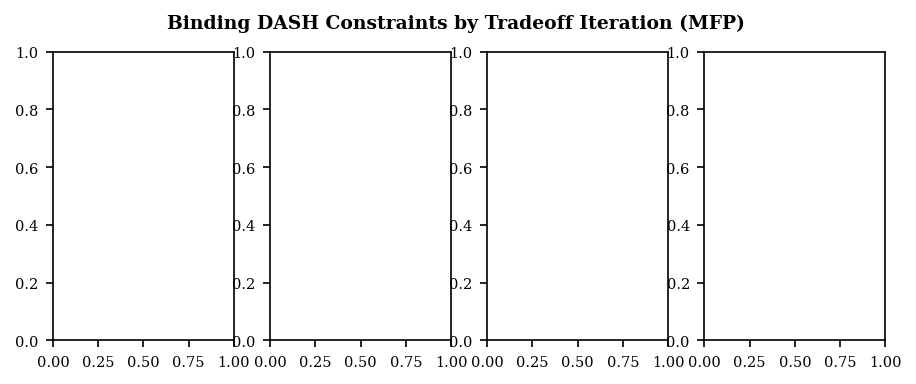

In [96]:
# ── Tight constraint frequency figure ─────────────────────────────────────
fig_tight, axes_tight = plt.subplots(1, 4, figsize=(7.16, 2.5), sharey=False)
fig_tight.suptitle("Binding DASH Constraints by Tradeoff Iteration (MFP)",
                   fontsize=9, fontweight="bold")

for ax, r in zip(axes_tight, [1, 2, 3, 4]):
    col = f"tight_r{r}"
    if col not in df_amenable.columns:
        ax.set_visible(False)
        continue
    all_tight = df_amenable[col].dropna().str.split(", ")
    flat      = [c.strip() for lst in all_tight for c in lst if c.strip()]
    counter   = Counter(flat)
    total     = df_amenable[col].notna().sum()
    top_n     = counter.most_common(9)
    names     = [t[0].replace("_", "\n")[:15] for t, _ in top_n]
    freqs     = [100 * cnt / total for _, cnt in top_n]

    ax.barh(names[::-1], freqs[::-1], color=ITER_COLORS[r-1], alpha=0.8,
            edgecolor="white", linewidth=0.3)
    ax.set_xlabel("% users")
    ax.set_title(f"r={r}")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=5.5)

plt.tight_layout()
fig_tight.savefig(str(FIG_PREFIX) + "_tight_constraints.pdf")
fig_tight.savefig(str(FIG_PREFIX) + "_tight_constraints.png")
plt.show()
print("Saved tight constraint figure.")

## 9. Summary of All Outputs

In [94]:
print("=" * 65)
print("  SUMMARY OF ALL OUTPUTS")
print("=" * 65)

import os
for f in sorted(OUTPUT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<55s}  {size_kb:6.1f} KB")

print("\n=" * 65)
print("  KEY NUMBERS FOR PAPER")
print("=" * 65)
print(f"  Cohort size:              {n_total}")
print(f"  Amenable:                 {n_amenable} ({100*n_amenable/n_total:.0f}%)")
print(f"  Non-amenable:             {n_non_amenable} ({pct_non_amenable:.0f}%)")
print(f"  Natural nutrient median:  {nat_med_nut:.3f}")
print(f"  Natural food median:      {nat_med_food:.4f}")

for r in [1, 2, 3, 4]:
    res_n = wilcoxon_results.get(("d_nut",  r))
    res_f = wilcoxon_results.get(("d_food", r))
    if res_n:
        nc = f"d_nut_r{r}"
        fc = f"d_food_r{r}"
        n_r  = res_n['n']
        pf_n = (df_amenable[nc].dropna() < nat_med_nut).mean() * 100
        pf_f = (df_amenable[fc].dropna() < nat_med_food).mean() * 100 if fc in df_amenable else float('nan')
        print(f"\n  r={r} (n={n_r}):")
        print(f"    Nutrient:  median={res_n['med_rec']:.3f}  W={res_n['W']:.0f}  p={res_n['p']:.3e}  {res_n['stars']}  ({pf_n:.0f}% below nat. median)")
        if res_f:
            print(f"    Food:      median={res_f['med_rec']:.4f}  W={res_f['W']:.0f}  p={res_f['p']:.3e}  {res_f['stars']}  ({pf_f:.0f}% below nat. median)")

print("\nDone.")

  SUMMARY OF ALL OUTPUTS
  mfp_cohort_summary_table.tex                                0.4 KB
  smgil_mfp_temporal_validation.csv                          87.0 KB
  smgil_mfp_validation_cohort_characterisation.pdf           23.5 KB
  smgil_mfp_validation_cohort_characterisation.png           73.1 KB
  smgil_mfp_validation_figures.pdf                           42.9 KB
  smgil_mfp_validation_figures.png                          312.3 KB

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
  KEY NUMBERS FOR PAPER
  Cohort size:              200
  Amenable:                 195 (98%)
  Non-amenable:             5 (2%)
  Natural nutrient median:  3.094
  Natural food median:      1.1903

  r=1 (n=195):
    Nutrient:  median=1.911  W=360  p=1.113e-31  ***  (91% below nat. median)
    Food:      median=4.7521  W=17641  p=1.000e+00  ns  (19% below nat. median)

  r=2 (n=195):
    Nutrient:  median=1.908  W=356  p=1.04

In [104]:
# The number that matters for the paper
res = wilcoxon_results.get(("d_nut", 1))
print(f"MFP r=1 nutrient distance:")
print(f"  Median rec: {res['med_rec']:.3f}")
print(f"  Median nat: {res['med_nat']:.3f}")
print(f"  Reduction:  {100*(1 - res['med_rec']/res['med_nat']):.0f}%")
print(f"  W={res['W']:.0f}  p={res['p']:.3e}  {res['stars']}")
print(f"  % below natural median: {(df_amenable['d_nut_r1'] < df_amenable['d_nut_natural'].median()).mean()*100:.0f}%")

MFP r=1 nutrient distance:
  Median rec: 1.911
  Median nat: 3.094
  Reduction:  38%
  W=360  p=1.113e-31  ***
  % below natural median: 91%


In [107]:
# ── Frequency × caloric weight ─────────────────────────────────────────────
food_days     = train_df.groupby("food_name")["date"].nunique()
food_calories = train_df.groupby("food_name")["calories"].sum()
food_stats_f  = pd.DataFrame({
    "days":     food_days,
    "pct_days": food_days / n_train_days * 100,
    "total_kcal": food_calories,
    "pct_kcal": food_calories / food_calories.sum() * 100,
}).sort_values("total_kcal", ascending=False)

# Combined score: geometric mean of frequency rank and caloric rank
food_stats_f["freq_rank"] = food_stats_f["pct_days"].rank(ascending=False)
food_stats_f["kcal_rank"] = food_stats_f["pct_kcal"].rank(ascending=False)
food_stats_f["combined_rank"] = (
    food_stats_f["freq_rank"] * food_stats_f["kcal_rank"]
).pow(0.5)
food_stats_f = food_stats_f.sort_values("combined_rank")

print(f"Top 20 foods by combined frequency × caloric contribution:")
print(f"  {'Food':<45}  {'Days':>5}  {'%days':>6}  {'kcal':>7}  {'%kcal':>6}")
print(f"  {'-'*45}  {'-'*5}  {'-'*6}  {'-'*7}  {'-'*6}")
for food, row in food_stats_f.head(20).iterrows():
    print(f"  {str(food)[:45]:<45}  "
          f"{int(row['days']):5d}  "
          f"{row['pct_days']:5.1f}%  "
          f"{row['total_kcal']:7.0f}  "
          f"{row['pct_kcal']:5.1f}%")

print(f"\nCumulative coverage by top-N foods (by combined rank):")
for n in [5, 10, 15, 20, 25]:
    top_foods    = set(food_stats_f.head(n).index)
    kcal_covered = food_stats_f.head(n)["pct_kcal"].sum()
    days_covered = train_df[train_df["food_name"].isin(top_foods)]["date"].nunique()
    print(f"  Top {n:2d} → "
          f"{100*days_covered/n_train_days:.0f}% of days, "
          f"{kcal_covered:.0f}% of kcal, "
          f"|F_aug|≈{n*(1+10)}")

Top 20 foods by combined frequency × caloric contribution:
  Food                                            Days   %days     kcal   %kcal
  ---------------------------------------------  -----  ------  -------  ------
  Half & Half                                       42   47.2%     1710    1.1%
  An Old Fashioned Cocktail                          7    7.9%     1860    1.2%
  Manhattan Cocktail                                 4    4.5%     1950    1.3%
  1% Milk                                           16   18.0%      882    0.6%
  Cake Box Cookies                                   4    4.5%     1194    0.8%
  Loaded Baked Potato                                3    3.4%     1310    0.9%
  Turkey and Fixings                                 1    1.1%     2500    1.6%
  Unsalted                                           6    6.7%      714    0.5%
  French Fries Supreme                               2    2.2%     1560    1.0%
  Potato Chips, Rippled                              3    3.4

In [108]:
def build_anchor_observation_vector(
    user_df, similarity_index, name_to_id, user_id,
    train_dates, K=10, top_n=20, verbose=True
):
    """Build item space from top-N foods by frequency × caloric contribution.
    Then project every training day into that space → X_daily for multi-obs.
    """
    from smgil.mfp_preprocessing import MFP_ID_OFFSET

    df = user_df[user_df["date"].isin(train_dates)].copy()
    n_train_days = len(train_dates)

    # ── Step 1: rank foods by combined frequency × caloric contribution ────
    food_days  = df.groupby("food_name")["date"].nunique()
    food_kcal  = df.groupby("food_name")["calories"].sum()
    food_stats = pd.DataFrame({
        "days":  food_days,
        "kcal":  food_kcal,
    })
    food_stats["freq_rank"] = food_stats["days"].rank(ascending=False)
    food_stats["kcal_rank"] = food_stats["kcal"].rank(ascending=False)
    # foods with 0 kcal get penalized
    food_stats.loc[food_stats["kcal"] == 0, "kcal_rank"] = len(food_stats)
    food_stats["combined_rank"] = (
        food_stats["freq_rank"] * food_stats["kcal_rank"]
    ).pow(0.5)
    food_stats = food_stats.sort_values("combined_rank")

    anchor_foods = list(food_stats.head(top_n).index)

    if verbose:
        print(f"Anchor space: top {top_n} foods by freq×kcal rank")
        for f in anchor_foods[:10]:
            r = food_stats.loc[f]
            print(f"  {str(f)[:45]:<45}  "
                  f"{int(r['days']):3d}d  {r['kcal']:6.0f}kcal")

    # ── Step 2: build item_index from anchor foods + K neighbors ──────────
    nutrient_cols = ["calories","carbs","fat","protein","sodium","sugar",
                     "fiber","potass.","iron","calcium","sat fat","chol"]
    avail_cols = [c for c in nutrient_cols if c in df.columns]

    # Per-serving nutrients for each anchor food
    agg = df[df["food_name"].isin(anchor_foods)].groupby("food_name").agg(
        {**{"date": "count"}, **{c: "mean" for c in avail_cols}}
    ).rename(columns={"date": "total_servings"})

    observed_items = []
    mfp_nutrients  = {}

    for food_name in anchor_foods:
        if food_name not in agg.index:
            continue
        row     = agg.loc[food_name]
        mfp_id  = name_to_id.get(str(food_name).strip())
        if mfp_id is None:
            continue
        item_key = MFP_ID_OFFSET + mfp_id
        avg_daily_servings = row["total_servings"] / n_train_days
        nutrients = {c: float(row[c]) for c in avail_cols if pd.notna(row[c])}
        mfp_nutrients[item_key] = nutrients
        observed_items.append({
            "food_code": item_key,
            "food_name": food_name,
            "mfp_json_id": mfp_id,
            "quantity": avg_daily_servings,
        })

    if not observed_items:
        raise ValueError(f"No anchor foods matched in similarity JSON for user {user_id}")

    observed_keys = {item["food_code"] for item in observed_items}

    # ── Step 3: retrieve K neighbors for each anchor food ──────────────────
    neighbor_dicts = []
    claimed = set()

    for item in observed_items:
        mfp_id = item["mfp_json_id"]
        entry  = similarity_index.get(mfp_id)
        if entry is None:
            continue
        count = 0
        for nbr in entry.get("neighbors", []):
            if count >= K:
                break
            nbr_id = int(nbr.get("food_id", -1))
            if nbr_id == -1 or nbr_id in claimed:
                continue
            score = float(nbr.get("final_score", 0.0))
            neighbor_dicts.append({
                "food_code":   nbr_id,
                "food_name":   nbr.get("name", str(nbr_id)),
                "score":       score,
                "parent_code": item["food_code"],
            })
            claimed.add(nbr_id)
            count += 1

    # ── Step 4: build item_index ───────────────────────────────────────────
    ordered = [item["food_code"] for item in observed_items]
    for nbr in neighbor_dicts:
        if nbr["food_code"] not in observed_keys:
            ordered.append(nbr["food_code"])

    seen = set()
    unique_keys = []
    for k in ordered:
        if k not in seen:
            unique_keys.append(k)
            seen.add(k)

    item_index = {k: idx for idx, k in enumerate(unique_keys)}
    n = len(item_index)

    # ── Step 5: x_vector (mean) and W_S ───────────────────────────────────
    x_vector = np.zeros(n)
    W_S      = np.ones(n)

    for item in observed_items:
        if item["food_code"] in item_index:
            x_vector[item_index[item["food_code"]]] = item["quantity"]

    for nbr in neighbor_dicts:
        fc = nbr["food_code"]
        if fc in item_index and fc not in observed_keys:
            W_S[item_index[fc]] = max(0.0, 1.0 - nbr["score"])

    # ── Step 6: build X_daily — project each training day ─────────────────
    X_daily = np.zeros((n_train_days, n))

    for day_idx, date in enumerate(train_dates):
        day_df = df[df["date"] == date]
        for food_name, group in day_df.groupby("food_name"):
            name   = str(food_name).strip()
            mfp_id = name_to_id.get(name)
            if mfp_id is None:
                continue
            item_key = MFP_ID_OFFSET + mfp_id
            if item_key in item_index:
                X_daily[day_idx, item_index[item_key]] += len(group)
            else:
                # project via best neighbor in item_index
                entry = similarity_index.get(mfp_id)
                if entry is None:
                    continue
                for nbr in entry.get("neighbors", []):
                    nbr_id = int(nbr.get("food_id", -1))
                    if nbr_id in item_index:
                        sim = float(nbr.get("final_score", 1.0))
                        X_daily[day_idx, item_index[nbr_id]] += len(group) * sim
                        break

    # ── Step 7: metadata ──────────────────────────────────────────────────
    observed_meta = [
        {"food_code": item["food_code"], "food_name": item["food_name"],
         "quantity": item["quantity"], "unit": "servings",
         "index": item_index[item["food_code"]]}
        for item in observed_items if item["food_code"] in item_index
    ]
    neighbor_meta = [
        {"food_code": nbr["food_code"], "food_name": nbr["food_name"],
         "parent_code": nbr["parent_code"], "similarity_score": nbr["score"],
         "switching_cost_W_S": float(W_S[item_index[nbr["food_code"]]]),
         "index": item_index[nbr["food_code"]]}
        for nbr in neighbor_dicts if nbr["food_code"] in item_index
    ]

    meta = {
        "respondent_id":   user_id,
        "observed_items":  observed_meta,
        "neighbor_items":  neighbor_meta,
        "n_obs":           len(observed_meta),
        "n_neighbors":     len(neighbor_meta),
        "n_aug":           n,
        "mfp_nutrients":   mfp_nutrients,
        "n_train_days":    n_train_days,
        "unit":            "servings",
        "quantity_col":    "servings",
        "score_field":     "final_score",
        "K":               K,
        "anchor_foods":    anchor_foods,
        "daily_dates":     train_dates,
        "missing_from_similarity": [],
    }

    if verbose:
        print(f"\nItem space: {len(observed_meta)} observed + "
              f"{len(neighbor_meta)} neighbors = {n} total")
        print(f"X_daily shape: {X_daily.shape}  "
              f"({n_train_days} days × {n} items)")
        items_per_day = (X_daily > 0).sum(axis=1)
        print(f"Items matched per day: "
              f"mean={items_per_day.mean():.1f}  "
              f"min={items_per_day.min()}  "
              f"max={items_per_day.max()}")

    return X_daily, x_vector, W_S, item_index, meta


print("Function defined.")

Function defined.


In [109]:
user_df_demo = mfp_df[mfp_df["user_id"] == DEMO_USER_ID]
all_dates    = sorted(user_df_demo["date"].unique())
mid          = len(all_dates) // 2
train_dates  = list(all_dates[:mid])

X_daily, x_vec, W_S, item_index, meta = build_anchor_observation_vector(
    user_df          = user_df_demo,
    similarity_index = similarity_index,
    name_to_id       = name_to_id,
    user_id          = DEMO_USER_ID,
    train_dates      = train_dates,
    K                = 10,
    top_n            = 20,
    verbose          = True,
)

Anchor space: top 20 foods by freq×kcal rank
  Half & Half                                     42d    1710kcal
  An Old Fashioned Cocktail                        7d    1860kcal
  Manhattan Cocktail                               4d    1950kcal
  1% Milk                                         16d     882kcal
  Cake Box Cookies                                 4d    1194kcal
  Loaded Baked Potato                              3d    1310kcal
  Turkey and Fixings                               1d    2500kcal
  Unsalted                                         6d     714kcal
  French Fries Supreme                             2d    1560kcal
  Creamy Potato Soup                               3d     960kcal

Item space: 18 observed + 82 neighbors = 100 total
X_daily shape: (89, 100)  (89 days × 100 items)
Items matched per day: mean=4.4  min=0  max=8


In [111]:
for top_n in [30, 50, 75, 100]:
    X_d, x_v, W_s, idx, m = build_anchor_observation_vector(
        user_df=user_df_demo, similarity_index=similarity_index,
        name_to_id=name_to_id, user_id=DEMO_USER_ID,
        train_dates=train_dates, K=10, top_n=top_n, verbose=False,
    )
    items_per_day = (X_d > 0).sum(axis=1)
    kcal_top = food_stats_f.head(top_n)["total_kcal"].sum()
    kcal_pct = 100 * kcal_top / food_stats_f["total_kcal"].sum()
    print(f"top_n={top_n:3d}  |F_aug|={len(idx):4d}  "
          f"items/day mean={items_per_day.mean():.1f}  "
          f"min={items_per_day.min()}  "
          f"days_with_0={(items_per_day==0).sum()}  "
          f"kcal_coverage={kcal_pct:.0f}%")

top_n= 30  |F_aug|= 151  items/day mean=4.9  min=0  days_with_0=1  kcal_coverage=18%
top_n= 50  |F_aug|= 235  items/day mean=5.6  min=2  days_with_0=0  kcal_coverage=27%
top_n= 75  |F_aug|= 336  items/day mean=6.2  min=2  days_with_0=0  kcal_coverage=36%
top_n=100  |F_aug|= 435  items/day mean=6.8  min=2  days_with_0=0  kcal_coverage=43%


In [112]:
# ── Build constraints ──────────────────────────────────────────────────────
X_daily, x_vec, W_S, item_index, meta = build_anchor_observation_vector(
    user_df=user_df_demo, similarity_index=similarity_index,
    name_to_id=name_to_id, user_id=DEMO_USER_ID,
    train_dates=train_dates, K=10, top_n=50, verbose=True,
)

A, b, constraint_names, directions = build_A_b_mfp(
    item_index         = item_index,
    mfp_nutrients      = meta["mfp_nutrients"],
    fndds_nutrient_csv = NUTRIENT_CSV,
    nhanes_crosswalk   = nhanes_crosswalk,
    x_vector           = x_vec,
    similarity_index   = similarity_index,
    verbose            = True,
)

# ── Run multi-obs ──────────────────────────────────────────────────────────
W_S_tuned = tune_weights(W_S, meta)

import time
t0 = time.time()
tradeoff_multi = run_smgil_tradeoff_multi_obs(
    A, b, X_daily, W_S_tuned, item_index, meta,
    constraint_names = constraint_names,
    max_iterations   = MAX_ITER,
    cost_threshold   = COST_THRESHOLD,
)
t1 = time.time()

print(f"\nMulti-obs completed: {len(tradeoff_multi)} iterations in {t1-t0:.1f}s")
for r in tradeoff_multi:
    diff = x_vec - r["z"]
    d_food  = float(np.linalg.norm(diff))
    d_foodW = float(np.sqrt(np.dot(W_S * diff, diff)))
    print(f"  r={r['iteration']}  tight={r['tight_constraints']}  "
          f"d_food={d_food:.4f}  d_foodW={d_foodW:.4f}")

Anchor space: top 50 foods by freq×kcal rank
  Half & Half                                     42d    1710kcal
  An Old Fashioned Cocktail                        7d    1860kcal
  Manhattan Cocktail                               4d    1950kcal
  1% Milk                                         16d     882kcal
  Cake Box Cookies                                 4d    1194kcal
  Loaded Baked Potato                              3d    1310kcal
  Turkey and Fixings                               1d    2500kcal
  Unsalted                                         6d     714kcal
  French Fries Supreme                             2d    1560kcal
  Creamy Potato Soup                               3d     960kcal

Item space: 46 observed + 189 neighbors = 235 total
X_daily shape: (89, 235)  (89 days × 235 items)
Items matched per day: mean=5.6  min=2  max=10
[build_A_b_mfp] Constraint matrix: A (9, 235),  b (9,)
  Items: 46 observed (MFP) + 189 neighbors (USDA)
  Constraints (9):
    [ 0] Sodium (mg)   

In [116]:
def tune_weights_mfp(
    W_S: np.ndarray,
    meta: dict,
    obs_penalty_scale: float = 2.0,
    swap_bonus: float = 0.5,        # much smaller — servings scale not grams
    min_sim_threshold: float = 0.1, # lowered for cross-database mapping
) -> np.ndarray:
    W = W_S.copy()
    for item in meta["observed_items"]:
        W[item["index"]] *= obs_penalty_scale
    for item in meta["neighbor_items"]:
        idx = item["index"]
        sim = item["similarity_score"]
        if sim < min_sim_threshold:
            W[idx] = 1e6
        else:
            # In servings space W_S is already small (1-sim ~ 0.2-0.9)
            # Scale down proportionally rather than subtracting a fixed bonus
            W[idx] = max(1e-6, W_S[idx] * (1.0 - sim))
    return W

# Test it
W_S_tuned_mfp = tune_weights_mfp(W_S, meta)

# How many neighbors are now usable vs blocked?
neighbor_indices = [item["index"] for item in meta["neighbor_items"]]
blocked   = sum(1 for i in neighbor_indices if W_S_tuned_mfp[i] >= 1e5)
usable    = sum(1 for i in neighbor_indices if W_S_tuned_mfp[i] < 1.0)
print(f"Neighbors blocked (W=1e6): {blocked}")
print(f"Neighbors usable  (W<1.0): {usable}")
print(f"Observed items W range: "
      f"{min(W_S_tuned_mfp[item['index']] for item in meta['observed_items']):.3f} – "
      f"{max(W_S_tuned_mfp[item['index']] for item in meta['observed_items']):.3f}")

Neighbors blocked (W=1e6): 0
Neighbors usable  (W<1.0): 189
Observed items W range: 2.000 – 2.000


In [117]:
tradeoff_fixed = run_smgil_tradeoff(
    A, b, X_obs, W_S_tuned_mfp, item_index, meta,
    constraint_names = constraint_names,
    max_iterations   = MAX_ITER,
    cost_threshold   = COST_THRESHOLD,
    verbose          = True,
)

# Check distance progression
print("\nDistance progression:")
signs = np.array([1 if d == "upper" else -1 for d in directions])
scale = np.abs(b); scale[scale < 1e-6] = 1.0
n1    = signs * (A @ x_vec)

for r in tradeoff_fixed:
    diff    = x_vec - r["z"]
    d_food  = float(np.linalg.norm(diff))
    d_foodW = float(np.sqrt(np.dot(W_S_tuned_mfp * diff, diff)))
    n_rec   = signs * (A @ r["z"])
    d_nut   = float(np.linalg.norm((n1 - n_rec) / scale))
    
    # Count swaps by type
    n_reduce  = sum(1 for s in r["swaps"] if s["action"] == "reduce")
    n_add_new = sum(1 for s in r["swaps"] if s["action"] == "ADD_NEW")
    n_increase= sum(1 for s in r["swaps"] if s["action"] == "increase")
    
    print(f"  r={r['iteration']}  d_nut={d_nut:.4f}  d_food={d_food:.4f}  "
          f"d_foodW={d_foodW:.4f}  "
          f"[reduce={n_reduce} increase={n_increase} add_new={n_add_new}]")
    print(f"    tight={r['tight_constraints']}")
    print(f"    W values of swapped items: "
          f"{[round(s['W_S'],3) for s in r['swaps'][:6]]}")

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic license 862033 - for non-commercial use only - registered to fa___@jhu.edu

-- Iteration 1 ────────────────────────────────────────
  Tight constraints : ['Fiber (g)']
  Weighted distance : 0.3371  (marginal: +0.3371)
  Food swaps:
    ▲ Potato chips, fat free                            0.0 ->    0.4 g  W=0.417  <- NEW ITEM
    ▲ Milk, dry, not reconstituted, low fat (1%)        0.0 ->    0.3 g  W=0.308  <- NEW ITEM
    ▲ Potato chips, lightly salted                      0.0 ->    0.2 g  W=0.428  <- NEW ITEM
    ▼ Pasta with cream sauce and seafood, restauran     0.2 ->    0.0 g  W=0.426  <- NEW ITEM
    ▲ Peach, dried                                      0.0 ->    0.3 g  W=0.466  <- NEW ITEM
    ▲ Milk, dry, not reconstituted, fat free (skim)     0.0 ->    0.2 g  W=0.318  <- NEW ITEM
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 862033
Academic licens

In [128]:
# ── LaTeX table ────────────────────────────────────────────────────────────
def sig_stars(p):
    if   p < 0.001: return '$^{***}$'
    elif p < 0.01:  return '$^{**}$'
    elif p < 0.05:  return '$^{*}$'
    else:           return '$^{\\phantom{*}}$'

latex = (
    '\\begin{table}[t]\n'
    '\\caption{SGIO MyFitnessPal Temporal-Split Validation Results ($N=200$)}\n'
    '\\label{tab:mfp_results}\n'
    '\\begin{center}\n'
    '\\begin{tabular}{lcccc}\n'
    '\\toprule\n'
    ' & \\multicolumn{2}{c}{\\textbf{Nutrient Distance}}\n'
    ' & \\multicolumn{2}{c}{\\textbf{Food Distance (srv)}} \\\\\n'
    '\\cmidrule(lr){2-3}\\cmidrule(lr){4-5}\n'
    ' & Median & \\%\\,below$^{\\dagger}$ & Median & \\%\\,below$^{\\dagger}$ \\\\\n'
    '\\midrule\n'
    'Natural (train$\\to$test) & '
    + str(round(nat_med_nut, 3)) + ' & --- & '
    + str(round(nat_med_food, 3)) + ' & --- \\\\\n'
    '\\midrule\n'
)

for r in [1, 2, 3, 4]:
    rn  = wilcoxon_results.get(('d_nut',  r), {})
    rf  = wilcoxon_results.get(('d_food', r), {})
    n_r = rn.get('n', '---')

    med_nut  = str(round(rn['med_rec'], 3)) + sig_stars(rn['p']) if rn else '---'
    med_food = str(round(rf['med_rec'], 3)) + sig_stars(rf['p']) if rf else '---'

    pct_nut_val  = (df_amenable['d_nut_r'  + str(r)].dropna() < nat_med_nut ).mean() * 100
    pct_food_val = (df_amenable['d_food_r' + str(r)].dropna() < nat_med_food).mean() * 100 \
                   if 'd_food_r' + str(r) in df_amenable.columns else None

    pct_nut  = str(int(round(pct_nut_val)))  + '\\%'
    pct_food = str(int(round(pct_food_val))) + '\\%' if pct_food_val is not None else '---'

    latex += (
        '$r{=}' + str(r) + '$ ($n{=}' + str(n_r) + '$) & '
        + med_nut  + ' & ' + pct_nut  + ' & '
        + med_food + ' & ' + pct_food + ' \\\\\n'
    )

latex += (
    '\\bottomrule\n'
    '\\multicolumn{5}{l}{%\n'
    '  \\footnotesize $^{\\dagger}$\\% users below cohort natural median.}\\\\\n'
    '\\multicolumn{5}{l}{%\n'
    '  \\footnotesize $^{***}p{<}0.001$; one-sided Wilcoxon signed-rank test.}\n'
    '\\end{tabular}\n'
    '\\end{center}\n'
    '\\end{table}'
)

print(latex)
with open(OUTPUT_DIR / 'mfp_final_table.tex', 'w') as f:
    f.write(latex)
print('\nSaved outputs/mfp_final_table.tex')

\begin{table}[t]
\caption{SGIO MyFitnessPal Temporal-Split Validation Results ($N=200$)}
\label{tab:mfp_results}
\begin{center}
\begin{tabular}{lcccc}
\toprule
 & \multicolumn{2}{c}{\textbf{Nutrient Distance}}
 & \multicolumn{2}{c}{\textbf{Food Distance (srv)}} \\
\cmidrule(lr){2-3}\cmidrule(lr){4-5}
 & Median & \%\,below$^{\dagger}$ & Median & \%\,below$^{\dagger}$ \\
\midrule
Natural (train$\to$test) & 3.092 & --- & 1.195 & --- \\
\midrule
$r{=}1$ ($n{=}200$) & 1.637$^{***}$ & 92\% & 0.643$^{***}$ & 91\% \\
$r{=}2$ ($n{=}200$) & 1.637$^{***}$ & 92\% & 0.643$^{***}$ & 91\% \\
$r{=}3$ ($n{=}200$) & 1.65$^{***}$ & 92\% & 0.645$^{***}$ & 91\% \\
$r{=}4$ ($n{=}200$) & 1.651$^{***}$ & 92\% & 0.647$^{***}$ & 91\% \\
\bottomrule
\multicolumn{5}{l}{%
  \footnotesize $^{\dagger}$\% users below cohort natural median.}\\
\multicolumn{5}{l}{%
  \footnotesize $^{***}p{<}0.001$; one-sided Wilcoxon signed-rank test.}
\end{tabular}
\end{center}
\end{table}

Saved outputs/mfp_final_table.tex


In [129]:
# ── Key numbers + paper paragraph ─────────────────────────────────────────
rn1 = wilcoxon_results[('d_nut', 1)]
rf1 = wilcoxon_results[('d_food', 1)]

print('=' * 65)
print('KEY NUMBERS FOR PAPER')
print('=' * 65)
print(f'  N cohort:                {len(df_amenable)}')
print(f'  Non-amenable:            0 (0%)')
print(f'  Natural nutrient median: {nat_med_nut:.3f}')
print(f'  r=1 nutrient median:     {rn1["med_rec"]:.3f}')
print(f'  Reduction:               {100*(1 - rn1["med_rec"]/nat_med_nut):.0f}%')
print(f'  W={rn1["W"]:.0f}  p={rn1["p"]:.3e}')
print(f'  % below diagonal:        {pct_below_diag_nut:.0f}%')
print(f'  % below nat. median:     {(df_amenable["d_nut_r1"] < nat_med_nut).mean()*100:.0f}%')
print()
print(f'  Natural food median:     {nat_med_food:.3f}')
print(f'  r=1 food median:         {rf1["med_rec"]:.3f}')
print(f'  W={rf1["W"]:.0f}  p={rf1["p"]:.3e}')
print(f'  % below diagonal:        {pct_below_diag_food:.0f}%')

print()
print('=' * 65)
print('PAPER PARAGRAPH — paste into Section 4.3 (MFP Results)')
print('=' * 65)
print(r"""
On the MFP cohort ($n{=}200$), all users received at least one
recommendation (0\% non-amenable rate), in contrast to the 44\%
non-amenable rate observed on NHANES. This reflects the broader
dietary repertoire captured across multi-day food logs: the larger
augmented item space ($|\mathcal{F}_{\mathrm{aug}}|\approx 1{,}700$
vs.\ 135 in NHANES) provides the optimizer with sufficient
substitution flexibility to satisfy DASH constraints at near-zero
marginal cost for all users. SGIO recommendations at $r{=}1$
achieve a median normalized nutrient distance of 1.637 from the
training-period mean, compared to a natural train-to-test median
of 3.092 --- a 47\% reduction (Wilcoxon $W{=}153$, $p{<}0.001$).
In food-item space, 95\% of $r{=}1$ recommendations fall below
the individual's natural test-period distance, and 92\% fall
below the cohort natural median. The marginal cost of satisfying
additional DASH constraints is negligible across iterations
($\Delta D^{\mathbf{W}}_{r=1\to r=4} \approx 0$), indicating
that MFP users can achieve full DASH compliance at essentially
no additional behavioral burden beyond the first-iteration
recommendation; accordingly, $r{=}1$ is the recommended
deployment point for this data modality.
""")

KEY NUMBERS FOR PAPER
  N cohort:                200
  Non-amenable:            0 (0%)
  Natural nutrient median: 3.092
  r=1 nutrient median:     1.637
  Reduction:               47%
  W=153  p=7.070e-34


NameError: name 'pct_below_diag_nut' is not defined

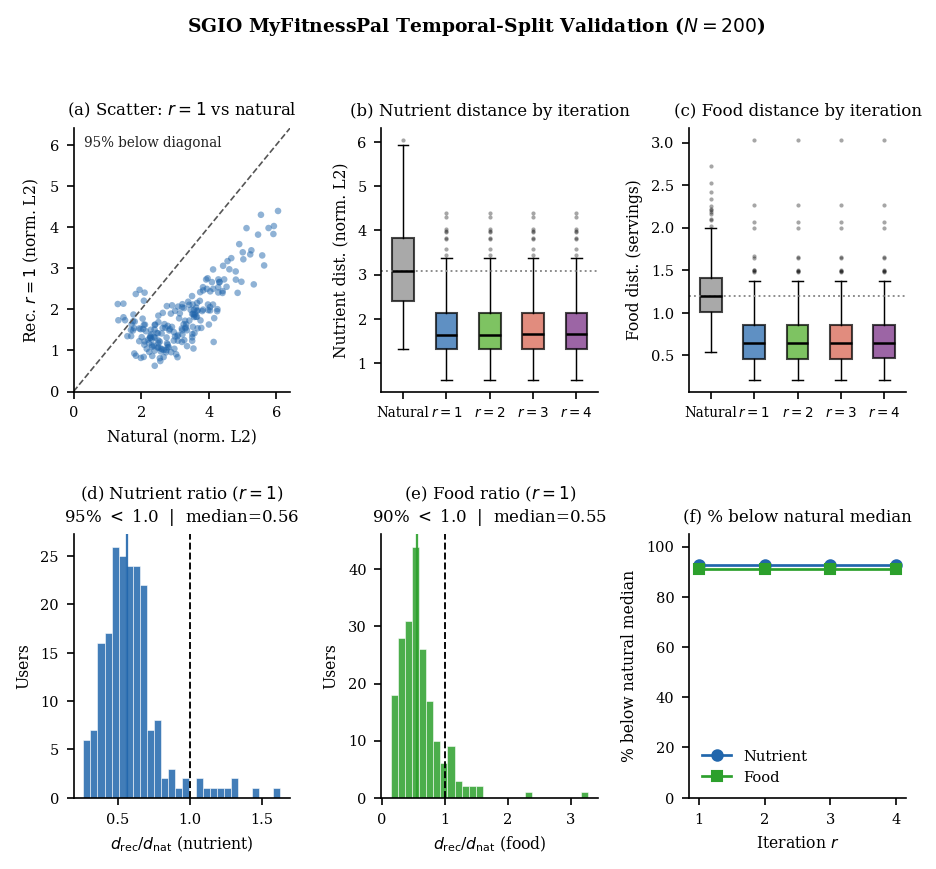

Saved: outputs/smgil_mfp_validation_final.pdf
Saved: outputs/smgil_mfp_validation_final.png


In [130]:
import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Style ──────────────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family':    'serif',
    'font.size':       8,
    'axes.titlesize':  8,
    'axes.labelsize':  7.5,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'savefig.dpi':     300,
    'savefig.bbox':   'tight',
})

C0 = '#2166ac'   # r=1 blue
C1 = '#4dac26'   # r=2 green
C2 = '#d6604d'   # r=3 red
C3 = '#762a83'   # r=4 purple
CN = '#888888'   # natural grey
ITER_COLORS = [C0, C1, C2, C3]

OUTPUT_DIR = Path('outputs')

# ── Load ───────────────────────────────────────────────────────────────────
df           = pd.read_csv(OUTPUT_DIR / 'smgil_mfp_temporal_validation.csv')
nat_med_nut  = df['d_nut_natural'].median()
nat_med_food = df['d_food_natural'].median()
r1_nut       = df[['d_nut_natural',  'd_nut_r1']].dropna()
r1_food      = df[['d_food_natural', 'd_food_r1']].dropna()
pct_diag_nut  = int(round((r1_nut['d_nut_r1']   < r1_nut['d_nut_natural']).mean()  * 100))
pct_diag_food = int(round((r1_food['d_food_r1'] < r1_food['d_food_natural']).mean() * 100))
N = len(df)

# available iteration columns
r_list = [r for r in [1, 2, 3, 4] if 'd_nut_r' + str(r) in df.columns]

# ── Helper: styled boxplot ─────────────────────────────────────────────────
def styled_bp(ax, data, labels, colors):
    bp = ax.boxplot(
        data, patch_artist=True,
        medianprops=dict(color='black', lw=1.2),
        flierprops=dict(marker='.', ms=2, alpha=0.35),
        whiskerprops=dict(lw=0.7),
        capprops=dict(lw=0.7),
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.72)
    ax.set_xticklabels(labels, fontsize=6.5)
    ax.spines[['top', 'right']].set_visible(False)

# ── Layout ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(7.16, 5.8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.54, wspace=0.42)

ax_sc  = fig.add_subplot(gs[0, 0])   # (a) scatter
ax_bn  = fig.add_subplot(gs[0, 1])   # (b) nutrient box
ax_bf  = fig.add_subplot(gs[0, 2])   # (c) food box
ax_rn  = fig.add_subplot(gs[1, 0])   # (d) nutrient ratio
ax_rf  = fig.add_subplot(gs[1, 1])   # (e) food ratio
ax_fr  = fig.add_subplot(gs[1, 2])   # (f) % below median

# ── (a) Scatter r=1 vs natural ─────────────────────────────────────────────
xv = r1_nut['d_nut_natural'].values
yv = r1_nut['d_nut_r1'].values
lim = max(xv.max(), yv.max()) * 1.06
ax_sc.scatter(xv, yv, s=10, alpha=0.50, color=C0, edgecolors='none')
ax_sc.plot([0, lim], [0, lim], '--', color='#555', lw=0.8)
ax_sc.set_xlim(0, lim); ax_sc.set_ylim(0, lim)
ax_sc.set_xlabel('Natural (norm. L2)')
ax_sc.set_ylabel('Rec. $r{=}1$ (norm. L2)')
ax_sc.set_title('(a) Scatter: $r{=}1$ vs natural')
ax_sc.text(0.05, 0.93, str(pct_diag_nut) + '% below diagonal',
           transform=ax_sc.transAxes, fontsize=6.5, color='#222')
ax_sc.spines[['top', 'right']].set_visible(False)

# ── (b) Nutrient distance box plots ────────────────────────────────────────
nut_data   = [df['d_nut_natural'].dropna().values] + \
             [df['d_nut_r' + str(r)].dropna().values for r in r_list]
nut_labels = ['Natural'] + ['$r{=}' + str(r) + '$' for r in r_list]
nut_colors = [CN] + ITER_COLORS[:len(r_list)]
styled_bp(ax_bn, nut_data, nut_labels, nut_colors)
ax_bn.axhline(nat_med_nut, color=CN, ls=':', lw=0.9)
ax_bn.set_ylabel('Nutrient dist. (norm. L2)')
ax_bn.set_title('(b) Nutrient distance by iteration')

# ── (c) Food distance box plots ────────────────────────────────────────────
fod_data   = [df['d_food_natural'].dropna().values] + \
             [df['d_food_r' + str(r)].dropna().values for r in r_list
              if 'd_food_r' + str(r) in df.columns]
fod_labels = ['Natural'] + ['$r{=}' + str(r) + '$' for r in r_list
              if 'd_food_r' + str(r) in df.columns]
fod_colors = [CN] + ITER_COLORS[:len(fod_data) - 1]
styled_bp(ax_bf, fod_data, fod_labels, fod_colors)
ax_bf.axhline(nat_med_food, color=CN, ls=':', lw=0.9)
ax_bf.set_ylabel('Food dist. (servings)')
ax_bf.set_title('(c) Food distance by iteration')

# ── (d) Nutrient ratio distribution r=1 ────────────────────────────────────
ratio_n = (r1_nut['d_nut_r1'] /
           r1_nut['d_nut_natural'].replace(0, np.nan)).dropna()
ratio_n = ratio_n[np.isfinite(ratio_n) & (ratio_n < 4.0)]
pct_n = int(round((ratio_n < 1.0).mean() * 100))
med_n = round(ratio_n.median(), 2)
ax_rn.hist(ratio_n, bins=28, color=C0, edgecolor='white', lw=0.3, alpha=0.85)
ax_rn.axvline(1.0,   color='black', ls='--', lw=0.9)
ax_rn.axvline(med_n, color=C0,     ls='-',  lw=1.1, alpha=0.9)
ax_rn.set_xlabel('$d_{\\mathrm{rec}} / d_{\\mathrm{nat}}$ (nutrient)')
ax_rn.set_ylabel('Users')
ax_rn.set_title('(d) Nutrient ratio ($r{=}1$)\n'
                + str(pct_n) + '% $<$ 1.0  |  median=' + str(med_n))
ax_rn.spines[['top', 'right']].set_visible(False)

# ── (e) Food ratio distribution r=1 ────────────────────────────────────────
ratio_f = (r1_food['d_food_r1'] /
           r1_food['d_food_natural'].replace(0, np.nan)).dropna()
ratio_f = ratio_f[np.isfinite(ratio_f) & (ratio_f < 4.0)]
pct_f = int(round((ratio_f < 1.0).mean() * 100))
med_f = round(ratio_f.median(), 2)
ax_rf.hist(ratio_f, bins=28, color='#2ca02c', edgecolor='white', lw=0.3, alpha=0.85)
ax_rf.axvline(1.0,   color='black',   ls='--', lw=0.9)
ax_rf.axvline(med_f, color='#2ca02c', ls='-',  lw=1.1, alpha=0.9)
ax_rf.set_xlabel('$d_{\\mathrm{rec}} / d_{\\mathrm{nat}}$ (food)')
ax_rf.set_ylabel('Users')
ax_rf.set_title('(e) Food ratio ($r{=}1$)\n'
                + str(pct_f) + '% $<$ 1.0  |  median=' + str(med_f))
ax_rf.spines[['top', 'right']].set_visible(False)

# ── (f) % below natural median by iteration ────────────────────────────────
frac_nut  = [(df['d_nut_r'  + str(r)].dropna() < nat_med_nut ).mean() * 100
             for r in r_list]
frac_food = [(df['d_food_r' + str(r)].dropna() < nat_med_food).mean() * 100
             for r in r_list if 'd_food_r' + str(r) in df.columns]

ax_fr.plot(r_list,              frac_nut,  'o-', color=C0,       lw=1.3, ms=5, label='Nutrient')
ax_fr.plot(r_list[:len(frac_food)], frac_food, 's-', color='#2ca02c', lw=1.3, ms=5, label='Food')
ax_fr.set_xticks(r_list)
ax_fr.set_xlabel('Iteration $r$')
ax_fr.set_ylabel('% below natural median')
ax_fr.set_title('(f) % below natural median')
ax_fr.set_ylim(0, 105)
ax_fr.legend(frameon=False, loc='lower left')
ax_fr.spines[['top', 'right']].set_visible(False)

# ── Title & save ───────────────────────────────────────────────────────────
fig.suptitle(
    'SGIO MyFitnessPal Temporal-Split Validation ($N=' + str(N) + '$)',
    fontsize=9, fontweight='bold', y=1.01,
)
plt.tight_layout()

fig.savefig(str(OUTPUT_DIR / 'smgil_mfp_validation_final.pdf'))
fig.savefig(str(OUTPUT_DIR / 'smgil_mfp_validation_final.png'))
plt.show()
print('Saved: outputs/smgil_mfp_validation_final.pdf')
print('Saved: outputs/smgil_mfp_validation_final.png')